# Interaction Term Model

## I. Data Preparation (The Foundation)
Prepare variables before fitting any interaction model:
1. Run the Box-Cox diagnostic early so target skewness is handled first.
2. Center continuous predictors using $x - \bar{x}$ so main effects are interpretable at average values of other predictors.

This avoids forcing interaction terms to absorb target non-normality or scaling artifacts.

=== Box-Cox Power Transformation Diagnostic ===
Target column: Item_Outlet_Sales
Applied positivity shift: 0.000000
Optimal lambda (MLE from scipy.stats.boxcox): 0.346765
Best lambda from tested grid [-2, 2]: 0.350000
Interpretation: use Box-Cox with lambda=0.347 (not a simple special case).


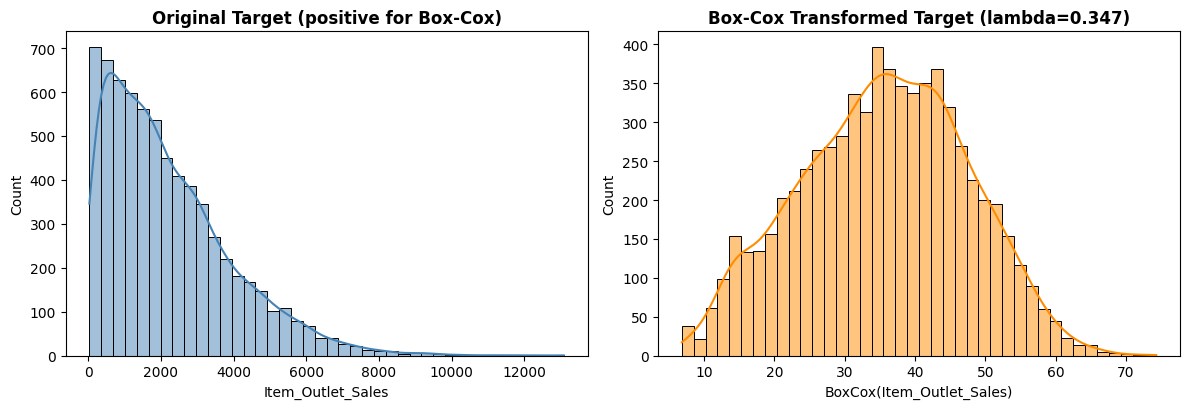

In [45]:
# 0.0 Box-Cox Power Transformation check
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import boxcox, boxcox_llf

boxcox_target = 'Item_Outlet_Sales'
boxcox_df = pd.read_csv('../data/train_data/train.csv')[[boxcox_target]].dropna().copy()
boxcox_series = boxcox_df[boxcox_target].astype(float)

# Box-Cox requires strictly positive values; shift only when needed.
shift_value = 0.0
if boxcox_series.min() <= 0:
    shift_value = 1.0 - float(boxcox_series.min())

boxcox_input = boxcox_series + shift_value
boxcox_transformed, optimal_lambda = boxcox(boxcox_input.values)

# Explicitly evaluate a lambda grid to show that we are testing a range.
lambda_grid = np.linspace(-2, 2, 161)
llf_values = [boxcox_llf(lmbda, boxcox_input.values) for lmbda in lambda_grid]
grid_best_lambda = float(lambda_grid[int(np.argmax(llf_values))])

if np.isclose(optimal_lambda, 1.0, atol=0.15):
    recommendation = 'lambda is near 1: no transformation is needed.'
elif np.isclose(optimal_lambda, 0.5, atol=0.15):
    recommendation = 'lambda is near 0.5: a square-root transformation is recommended.'
elif np.isclose(optimal_lambda, 0.0, atol=0.15):
    recommendation = 'lambda is near 0: a log transformation is mathematically optimal.'
else:
    recommendation = f'use Box-Cox with lambda={optimal_lambda:.3f} (not a simple special case).'

print('=== Box-Cox Power Transformation Diagnostic ===')
print(f'Target column: {boxcox_target}')
print(f'Applied positivity shift: {shift_value:.6f}')
print(f'Optimal lambda (MLE from scipy.stats.boxcox): {optimal_lambda:.6f}')
print(f'Best lambda from tested grid [-2, 2]: {grid_best_lambda:.6f}')
print(f'Interpretation: {recommendation}')

plt.figure(figsize=(12, 4.2))
plt.subplot(1, 2, 1)
sns.histplot(boxcox_input, kde=True, bins=40, color='steelblue')
plt.title('Original Target (positive for Box-Cox)', fontweight='bold')
plt.xlabel(boxcox_target)

plt.subplot(1, 2, 2)
sns.histplot(boxcox_transformed, kde=True, bins=40, color='darkorange')
plt.title(f'Box-Cox Transformed Target (lambda={optimal_lambda:.3f})', fontweight='bold')
plt.xlabel(f'BoxCox({boxcox_target})')

plt.tight_layout()
plt.show()

### I.1 Build Modeling Table and Center Predictors
Load training data, apply the selected Box-Cox transform to the target, then create centered versions of every continuous predictor before any baseline or interaction model is fit.

In [46]:
import itertools
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import boxcox

import statsmodels.formula.api as smf

# Load training data for the interaction workflow
screen_df = pd.read_csv('../data/train_data/train.csv')

# Apply Box-Cox transformation to the target variable using the lambda checked in Step I.
optimal_lambda = float(globals().get('optimal_lambda', 0.347))
if screen_df['Item_Outlet_Sales'].min() <= 0:
    raise ValueError('Item_Outlet_Sales must be strictly positive for Box-Cox transformation.')
screen_df['Sales_Transformed'] = boxcox(screen_df['Item_Outlet_Sales'], lmbda=optimal_lambda)

target_col = 'Sales_Transformed'
screen_continuous_cols = ['Item_Weight', 'Item_Visibility', 'Item_MRP', 'Outlet_Years']
screen_categorical_cols = [
    'Item_Fat_Content',
    'Item_Type',
    'Outlet_Size',
    'Outlet_Location_Type',
    'Outlet_Type'
 ]

screen_used_cols = [target_col] + screen_continuous_cols + screen_categorical_cols
screen_df = screen_df[screen_used_cols].copy()

for col in screen_categorical_cols:
    screen_df[col] = screen_df[col].astype('category')

# Center continuous predictors before any model fitting so main effects stay interpretable.
centered_map = {}
for col in screen_continuous_cols:
    centered_col = f'{col}_Centered'
    screen_df[centered_col] = screen_df[col] - screen_df[col].mean()
    centered_map[col] = centered_col
screen_centered_continuous_cols = [centered_map[c] for c in screen_continuous_cols]

print(f'Rows used for modeling: {screen_df.shape[0]}')
print(f'Target variable: {target_col} (Box-Cox, lambda={optimal_lambda:.3f})')
print(f'Continuous variables (raw, for screening visuals): {screen_continuous_cols}')
print(f'Continuous variables (centered, for modeling): {screen_centered_continuous_cols}')
print(f'Categorical variables: {screen_categorical_cols}')
print('Means of centered variables (should be near zero):')
display(screen_df[screen_centered_continuous_cols].mean().to_frame('mean').T)

Rows used for modeling: 6818
Target variable: Sales_Transformed (Box-Cox, lambda=0.347)
Continuous variables (raw, for screening visuals): ['Item_Weight', 'Item_Visibility', 'Item_MRP', 'Outlet_Years']
Continuous variables (centered, for modeling): ['Item_Weight_Centered', 'Item_Visibility_Centered', 'Item_MRP_Centered', 'Outlet_Years_Centered']
Categorical variables: ['Item_Fat_Content', 'Item_Type', 'Outlet_Size', 'Outlet_Location_Type', 'Outlet_Type']
Means of centered variables (should be near zero):


,Item_Weight_Centered,Item_Visibility_Centered,Item_MRP_Centered,Outlet_Years_Centered
mean,1.050494e-15,-2.817081e-18,-6.069523e-15,4.835609e-16


## II. Baseline Model (Main Effects Only)
Fit a benchmark model with centered continuous main effects and categorical main effects only. Then inspect residual structure; visible pattern (curve or fan/funnel) is the evidence needed before moving to interaction terms.

Baseline formula (main effects only): Sales_Transformed ~ Item_Weight_Centered + Item_Visibility_Centered + Item_MRP_Centered + Outlet_Years_Centered + C(Item_Fat_Content) + C(Item_Type) + C(Outlet_Size) + C(Outlet_Location_Type) + C(Outlet_Type)
Baseline R-squared: 0.6786
Baseline Adj. R-squared: 0.6773


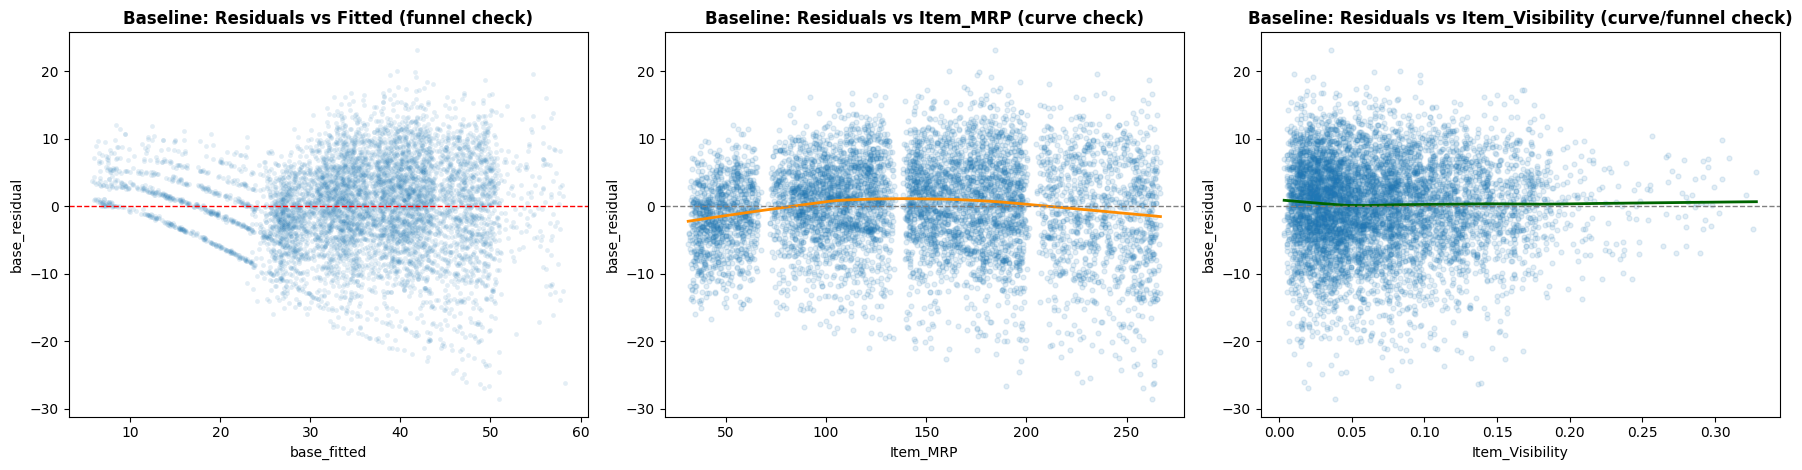

Baseline funnel proxy corr(|residual|, fitted): 0.2083
Residual funnel signal detected -> interaction screening is justified.
Top Continuous x Continuous residual interaction signals:


,var_1,var_2,pair,resid_corr_with_product,abs_score
0,Item_Visibility,Item_MRP,Item_Visibility : Item_MRP,-0.061963,0.061963
1,Item_Weight,Item_MRP,Item_Weight : Item_MRP,0.012522,0.012522
2,Item_Weight,Item_Visibility,Item_Weight : Item_Visibility,-0.009040,0.009040
3,Item_Weight,Outlet_Years,Item_Weight : Outlet_Years,0.008488,0.008488
4,Item_MRP,Outlet_Years,Item_MRP : Outlet_Years,-0.007147,0.007147
5,Item_Visibility,Outlet_Years,Item_Visibility : Outlet_Years,0.003786,0.003786


Top Continuous x Categorical residual interaction signals:


,continuous_var,categorical_var,pair,slope_spread,abs_score
0,Item_Visibility,Item_Type,Item_Visibility : Item_Type,31.865890,31.865890
1,Item_Visibility,Outlet_Type,Item_Visibility : Outlet_Type,9.207688,9.207688
2,Item_Visibility,Outlet_Size,Item_Visibility : Outlet_Size,9.029359,9.029359
3,Item_Visibility,Outlet_Location_Type,Item_Visibility : Outlet_Location_Type,8.283836,8.283836
4,Item_Visibility,Item_Fat_Content,Item_Visibility : Item_Fat_Content,6.272756,6.272756
5,Item_Weight,Item_Type,Item_Weight : Item_Type,0.545622,0.545622
6,Outlet_Years,Item_Type,Outlet_Years : Item_Type,0.232592,0.232592
7,Item_Weight,Outlet_Size,Item_Weight : Outlet_Size,0.078331,0.078331
8,Item_MRP,Outlet_Type,Item_MRP : Outlet_Type,0.069613,0.069613
9,Item_Weight,Outlet_Type,Item_Weight : Outlet_Type,0.067437,0.067437


In [47]:
# II.A Baseline benchmark and residual diagnostics (no interaction terms)
baseline_cont_terms = list(globals().get('screen_centered_continuous_cols', screen_continuous_cols))
baseline_cat_terms = [f'C({c})' for c in screen_categorical_cols]
base_terms = baseline_cont_terms + baseline_cat_terms
base_formula = f"{target_col} ~ " + ' + '.join(base_terms)
base_model = smf.ols(base_formula, data=screen_df).fit()

screen_df = screen_df.copy()
screen_df['base_fitted'] = base_model.fittedvalues
screen_df['base_residual'] = base_model.resid

print(f'Baseline formula (main effects only): {base_formula}')
print(f'Baseline R-squared: {base_model.rsquared:.4f}')
print(f'Baseline Adj. R-squared: {base_model.rsquared_adj:.4f}')

fig, axes = plt.subplots(1, 3, figsize=(18, 4.8))

sns.scatterplot(
    data=screen_df,
    x='base_fitted',
    y='base_residual',
    alpha=0.12,
    s=12,
    ax=axes[0]
 )
axes[0].axhline(0, color='red', linestyle='--', linewidth=1)
axes[0].set_title('Baseline: Residuals vs Fitted (funnel check)', fontweight='bold')

sns.regplot(
    data=screen_df,
    x='Item_MRP',
    y='base_residual',
    lowess=True,
    scatter_kws={'alpha': 0.12, 's': 12},
    line_kws={'color': 'darkorange', 'linewidth': 2},
    ax=axes[1]
 )
axes[1].axhline(0, color='gray', linestyle='--', linewidth=1)
axes[1].set_title('Baseline: Residuals vs Item_MRP (curve check)', fontweight='bold')

sns.regplot(
    data=screen_df,
    x='Item_Visibility',
    y='base_residual',
    lowess=True,
    scatter_kws={'alpha': 0.12, 's': 12},
    line_kws={'color': 'darkgreen', 'linewidth': 2},
    ax=axes[2]
 )
axes[2].axhline(0, color='gray', linestyle='--', linewidth=1)
axes[2].set_title('Baseline: Residuals vs Item_Visibility (curve/funnel check)', fontweight='bold')

plt.tight_layout()
plt.show()

funnel_corr = np.corrcoef(screen_df['base_fitted'], np.abs(screen_df['base_residual']))[0, 1]
print(f'Baseline funnel proxy corr(|residual|, fitted): {funnel_corr:.4f}')
if abs(funnel_corr) > 0.10:
    print('Residual funnel signal detected -> interaction screening is justified.')
else:
    print('Weak funnel signal, but we still continue with systematic interaction screening.')

# Continuous x Continuous screening signal: corr(residual, centered product term)
cont_cont_scores = []
for var_1, var_2 in itertools.combinations(screen_continuous_cols, 2):
    left = centered_map.get(var_1, var_1)
    right = centered_map.get(var_2, var_2)
    product_term = screen_df[left] * screen_df[right]
    corr_with_resid = np.corrcoef(screen_df['base_residual'], product_term)[0, 1]
    cont_cont_scores.append({
        'var_1': var_1,
        'var_2': var_2,
        'pair': f'{var_1} : {var_2}',
        'resid_corr_with_product': corr_with_resid,
        'abs_score': abs(corr_with_resid)
    })
cont_cont_resid_scores_df = pd.DataFrame(cont_cont_scores).sort_values('abs_score', ascending=False).reset_index(drop=True)

# Continuous x Categorical screening signal: slope spread by category
cont_cat_scores = []
for cont_var in screen_continuous_cols:
    for cat_var in screen_categorical_cols:
        slopes = []
        for _, group_df in screen_df.groupby(cat_var, observed=True):
            if group_df.shape[0] >= 40 and group_df[cont_var].nunique() > 2:
                slope = np.polyfit(group_df[cont_var], group_df['base_residual'], 1)[0]
                slopes.append(slope)
        if len(slopes) >= 2:
            slope_spread = float(np.max(slopes) - np.min(slopes))
            cont_cat_scores.append({
                'continuous_var': cont_var,
                'categorical_var': cat_var,
                'pair': f'{cont_var} : {cat_var}',
                'slope_spread': slope_spread,
                'abs_score': abs(slope_spread)
            })

if cont_cat_scores:
    cont_cat_resid_scores_df = pd.DataFrame(cont_cat_scores).sort_values('abs_score', ascending=False).reset_index(drop=True)
else:
    cont_cat_resid_scores_df = pd.DataFrame(
        columns=['continuous_var', 'categorical_var', 'pair', 'slope_spread', 'abs_score']
    )

print('Top Continuous x Continuous residual interaction signals:')
display(cont_cont_resid_scores_df.head(10))
print('Top Continuous x Categorical residual interaction signals:')
display(cont_cat_resid_scores_df.head(10))

## III. Systematic Interaction & Non-linearity Screening (Candidate Phase)
Use filter-based screening before any large interaction model:
1. Categorical x Categorical via cross-cell mean deviations and Two-Way ANOVA.
2. Continuous x Categorical via grouped slope inconsistencies.
3. Continuous x Continuous via correlation structure and residual-product signals from the baseline model.

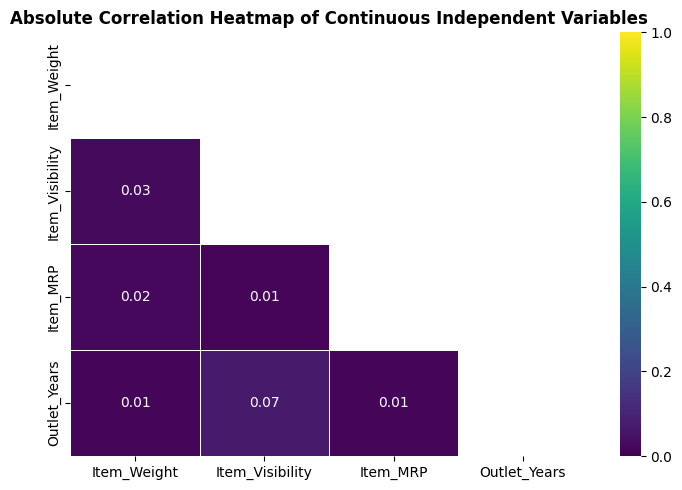

Top continuous-variable pairs by absolute correlation:


,var_1,var_2,corr,abs_corr
0,Item_Visibility,Outlet_Years,0.069742,0.069742
1,Item_Weight,Item_Visibility,-0.026322,0.026322
2,Item_Weight,Item_MRP,0.023157,0.023157
3,Item_MRP,Outlet_Years,-0.014577,0.014577
4,Item_Weight,Outlet_Years,0.012237,0.012237
5,Item_Visibility,Item_MRP,-0.011075,0.011075


In [48]:
# 0.1 Heatmap: absolute correlations are early interaction candidates
corr_matrix = screen_df[screen_continuous_cols].corr()
abs_corr_matrix = corr_matrix.abs()

plt.figure(figsize=(7, 5))
mask = np.triu(np.ones_like(abs_corr_matrix, dtype=bool))
sns.heatmap(
    abs_corr_matrix,
    mask=mask,
    annot=True,
    fmt='.2f',
    cmap='viridis',
    vmin=0,
    vmax=1,
    linewidths=0.5
 )
plt.title('Absolute Correlation Heatmap of Continuous Independent Variables', fontweight='bold')
plt.tight_layout()
plt.show()

upper_i, upper_j = np.triu_indices_from(corr_matrix, k=1)
heatmap_candidates_df = pd.DataFrame({
    'var_1': [corr_matrix.index[i] for i in upper_i],
    'var_2': [corr_matrix.columns[j] for j in upper_j],
    'corr': [corr_matrix.iloc[i, j] for i, j in zip(upper_i, upper_j)],
    'abs_corr': [abs_corr_matrix.iloc[i, j] for i, j in zip(upper_i, upper_j)]
})
heatmap_candidates_df = heatmap_candidates_df.sort_values('abs_corr', ascending=False).reset_index(drop=True)

print('Top continuous-variable pairs by absolute correlation:')
display(heatmap_candidates_df.head(10))

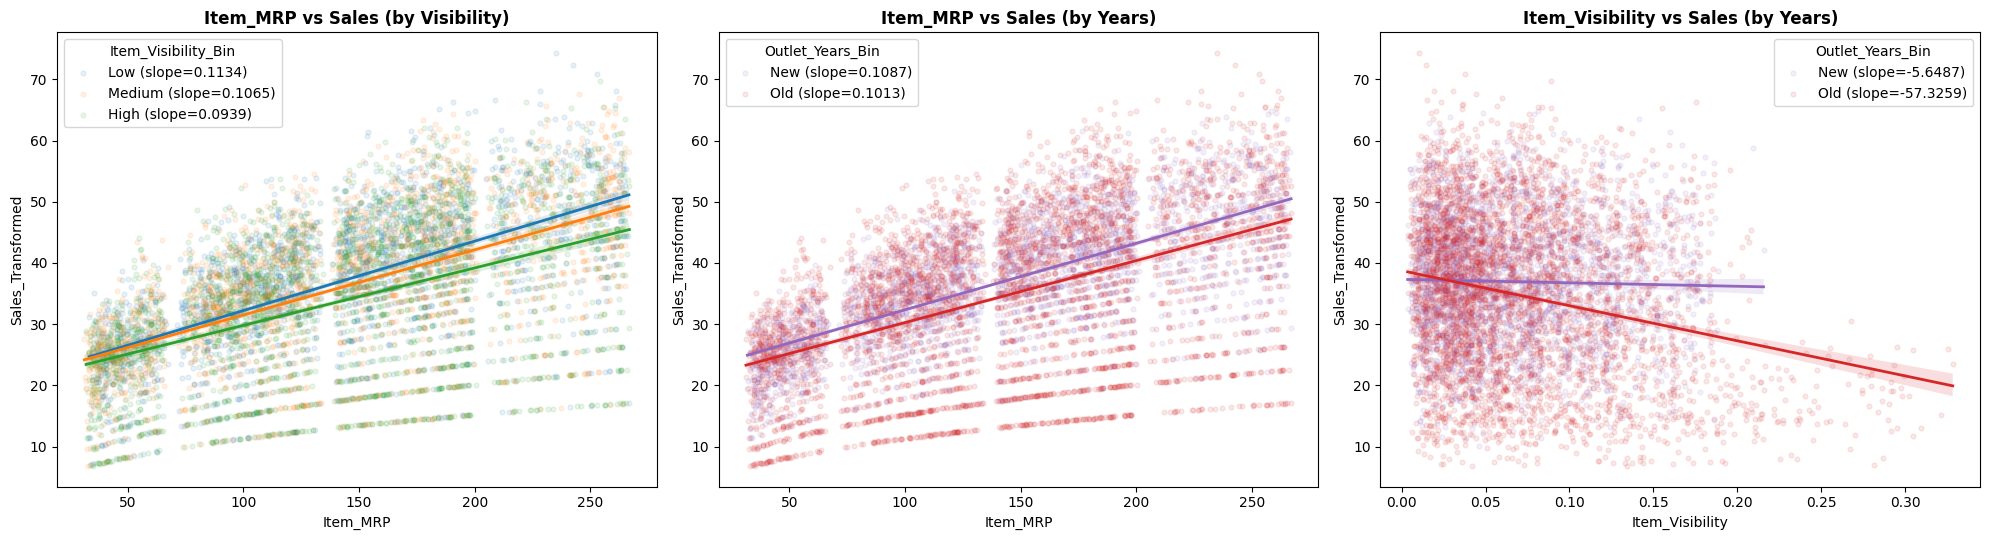

Interaction screening table for all 6 continuous x continuous terms:


,term,Coef.,Std.Err.,t,p_value,decision
0,Item_Visibility:Outlet_Years,-2.687179,0.276022,-9.735362,2.974735e-22,Keep (p < 0.05)
1,Item_Visibility:Item_MRP,-0.159536,0.037612,-4.241636,2.248360e-05,Keep (p < 0.05)
2,Item_Weight:Item_MRP,0.000638,0.000411,1.550860,1.209818e-01,Discard (p >= 0.05)
3,Item_Weight:Outlet_Years,0.000475,0.002992,0.158836,8.738027e-01,Discard (p >= 0.05)
4,Item_MRP:Outlet_Years,-0.000022,0.000222,-0.099873,9.204482e-01,Discard (p >= 0.05)
5,Item_Weight:Item_Visibility,0.040741,0.506258,0.080476,9.358613e-01,Discard (p >= 0.05)


Kept interactions: ['Item_Visibility:Outlet_Years', 'Item_Visibility:Item_MRP']
Discarded interactions: ['Item_Weight:Item_MRP', 'Item_Weight:Outlet_Years', 'Item_MRP:Outlet_Years', 'Item_Weight:Item_Visibility']

VIF for candidate model terms (before centering check):


,term,VIF
0,Item_Visibility,13.437623
1,Item_Visibility:Item_MRP,13.183937
2,Item_Visibility:Outlet_Years,11.262478
3,Item_MRP,10.848124
4,Outlet_Years,9.079513
5,Item_Weight,6.896444



Centering applied because at least one kept interaction had VIF > 10.
Final VIF table (after optional centering):


...


AIC/BIC comparison (lower is better):


,model,AIC,BIC,Delta_AIC_vs_Baseline,Delta_BIC_vs_Baseline
0,Baseline (no interactions),50313.938999,50348.075606,0.000000,0.00000
1,Interaction model (final),50203.913376,50251.704627,-110.025622,-96.37098


AIC improved: interactions add explanatory value beyond complexity.
BIC improved: interactions are favored under a stricter complexity penalty.

Final model formula used for interpretation:


<IPython.core.display.Math object>

Centering applied: True


In [49]:
# 0.1d Visualization phase (binning) + statistical phase (6 continuous interaction terms)
from statsmodels.stats.outliers_influence import variance_inflation_factor
from IPython.display import display, Math

phase_df = screen_df[[target_col] + screen_continuous_cols].copy()

# ------------------------------
# Visualization phase: discretization (binning)
# ------------------------------
# Item_Visibility binned into quantile groups for slope comparison against Item_MRP.
phase_df['Item_Visibility_Bin'] = pd.qcut(
    phase_df['Item_Visibility'],
    q=3,
    labels=['Low', 'Medium', 'High'],
    duplicates='drop'
 )

# Outlet_Years binned into New vs Old stores using median split.
years_cutoff = float(phase_df['Outlet_Years'].median())
phase_df['Outlet_Years_Bin'] = np.where(phase_df['Outlet_Years'] >= years_cutoff, 'Old', 'New')
phase_df['Outlet_Years_Bin'] = pd.Categorical(phase_df['Outlet_Years_Bin'], categories=['New', 'Old'], ordered=True)

fig, axes = plt.subplots(1, 3, figsize=(20, 5.5))

visibility_palette = {'Low': '#1f77b4', 'Medium': '#ff7f0e', 'High': '#2ca02c'}
for vis_bin, grp in phase_df.groupby('Item_Visibility_Bin', observed=True):
    if grp.shape[0] < 10 or grp['Item_MRP'].nunique() < 3:
        continue
    slope = np.polyfit(grp['Item_MRP'], grp[target_col], 1)[0]
    sns.regplot(
        data=grp,
        x='Item_MRP',
        y=target_col,
        scatter_kws={'alpha': 0.10, 's': 12},
        line_kws={'linewidth': 2},
        color=visibility_palette.get(str(vis_bin), None),
        ax=axes[0],
        label=f"{vis_bin} (slope={slope:.4f})"
    )

axes[0].set_title('Item_MRP vs Sales (by Visibility)', fontweight='bold')
axes[0].set_ylabel(f'{target_col}')
axes[0].legend(title='Item_Visibility_Bin')

years_palette = {'New': '#9467bd', 'Old': '#d62728'}
for years_bin, grp in phase_df.groupby('Outlet_Years_Bin', observed=True):
    if grp.shape[0] < 10 or grp['Item_MRP'].nunique() < 3:
        continue
    slope = np.polyfit(grp['Item_MRP'], grp[target_col], 1)[0]
    sns.regplot(
        data=grp,
        x='Item_MRP',
        y=target_col,
        scatter_kws={'alpha': 0.10, 's': 12},
        line_kws={'linewidth': 2},
        color=years_palette.get(str(years_bin), None),
        ax=axes[1],
        label=f"{years_bin} (slope={slope:.4f})"
    )

axes[1].set_title('Item_MRP vs Sales (by Years)', fontweight='bold')
axes[1].set_ylabel(f'{target_col}')
axes[1].legend(title=f'Outlet_Years_Bin')

for years_bin, grp in phase_df.groupby('Outlet_Years_Bin', observed=True):
    if grp.shape[0] < 10 or grp['Item_Visibility'].nunique() < 3:
        continue
    slope = np.polyfit(grp['Item_Visibility'], grp[target_col], 1)[0]
    sns.regplot(
        data=grp,
        x='Item_Visibility',
        y=target_col,
        scatter_kws={'alpha': 0.10, 's': 12},
        line_kws={'linewidth': 2},
        color=years_palette.get(str(years_bin), None),
        ax=axes[2],
        label=f"{years_bin} (slope={slope:.4f})"
    )

axes[2].set_title('Item_Visibility vs Sales (by Years)', fontweight='bold')
axes[2].set_ylabel(f'{target_col}')
axes[2].legend(title=f'Outlet_Years_Bin')

plt.tight_layout()
plt.show()

# ------------------------------
# Statistical phase: one OLS with all 6 continuous x continuous interactions
# ------------------------------
interaction_pairs = list(itertools.combinations(screen_continuous_cols, 2))
interaction_terms = [f'{a}:{b}' for a, b in interaction_pairs]
main_formula_part = ' + '.join(screen_continuous_cols)
interaction_formula_part = ' + '.join(interaction_terms)

six_interaction_formula = f"{target_col} ~ {main_formula_part} + {interaction_formula_part}"
six_interaction_model = smf.ols(six_interaction_formula, data=phase_df).fit()

coef_table = (
    six_interaction_model.summary2().tables[1]
    .reset_index()
    .rename(columns={'index': 'term', 'P>|t|': 'p_value'})
)

interaction_results_df = (
    coef_table[coef_table['term'].isin(interaction_terms)][['term', 'Coef.', 'Std.Err.', 't', 'p_value']]
    .sort_values('p_value')
    .reset_index(drop=True)
)

interaction_results_df['decision'] = np.where(
    interaction_results_df['p_value'] < 0.05,
    'Keep (p < 0.05)',
    'Discard (p >= 0.05)'
)

print('Interaction screening table for all 6 continuous x continuous terms:')
display(interaction_results_df)

kept_interactions = interaction_results_df.loc[
    interaction_results_df['p_value'] < 0.05,
    'term'
].tolist()

discarded_interactions = interaction_results_df.loc[
    interaction_results_df['p_value'] >= 0.05,
    'term'
].tolist()

print(f'Kept interactions: {kept_interactions if kept_interactions else "None"}')
print(f'Discarded interactions: {discarded_interactions if discarded_interactions else "None"}')

# Build candidate model with only significant interactions (if any), while retaining main effects.
candidate_formula = f"{target_col} ~ {main_formula_part}"
if kept_interactions:
    candidate_formula += ' + ' + ' + '.join(kept_interactions)

candidate_model = smf.ols(candidate_formula, data=phase_df).fit()

def compute_vif_table(model):
    exog = pd.DataFrame(model.model.exog, columns=model.model.exog_names).copy()
    if 'Intercept' in exog.columns:
        exog = exog.drop(columns=['Intercept'])

    vif_rows = []
    for idx, col_name in enumerate(exog.columns):
        vif_rows.append({
            'term': col_name,
            'VIF': float(variance_inflation_factor(exog.values, idx))
        })

    vif_df = pd.DataFrame(vif_rows).sort_values('VIF', ascending=False).reset_index(drop=True)
    return vif_df

initial_vif_df = compute_vif_table(candidate_model)
print('\nVIF for candidate model terms (before centering check):')
display(initial_vif_df)

high_vif_terms = initial_vif_df.loc[initial_vif_df['VIF'] > 10, 'term'].tolist()
high_vif_interactions = [term for term in high_vif_terms if ':' in term and term in kept_interactions]

final_model = candidate_model
final_formula = candidate_formula
centering_applied = False

# Fix for high VIF in significant continuous interactions: mean-center variables before creating products.
if high_vif_interactions:
    centered_map = {}
    for col in screen_continuous_cols:
        centered_col = f'{col}_Centered'
        phase_df[centered_col] = phase_df[col] - phase_df[col].mean()
        centered_map[col] = centered_col

    centered_main = [centered_map[c] for c in screen_continuous_cols]
    centered_kept_interactions = []
    for term in kept_interactions:
        left, right = term.split(':')
        centered_kept_interactions.append(f"{centered_map[left]}:{centered_map[right]}")

    final_formula = f"{target_col} ~ " + ' + '.join(centered_main)
    if centered_kept_interactions:
        final_formula += ' + ' + ' + '.join(centered_kept_interactions)

    final_model = smf.ols(final_formula, data=phase_df).fit()
    centering_applied = True
    print('\nCentering applied because at least one kept interaction had VIF > 10.')
else:
    print('\nNo centering needed based on VIF threshold > 10 for kept interactions.')

final_vif_df = compute_vif_table(final_model)
print('Final VIF table (after optional centering):')
display(final_vif_df)

# ------------------------------
# Model comparison: interaction model vs no-interaction baseline
# ------------------------------
baseline_formula = f"{target_col} ~ {main_formula_part}"
baseline_model = smf.ols(baseline_formula, data=phase_df).fit()

comparison_df = pd.DataFrame([
    {
        'model': 'Baseline (no interactions)',
        'AIC': baseline_model.aic,
        'BIC': baseline_model.bic
    },
    {
        'model': 'Interaction model (final)',
        'AIC': final_model.aic,
        'BIC': final_model.bic
    }
])

comparison_df['Delta_AIC_vs_Baseline'] = comparison_df['AIC'] - baseline_model.aic
comparison_df['Delta_BIC_vs_Baseline'] = comparison_df['BIC'] - baseline_model.bic

print('\nAIC/BIC comparison (lower is better):')
display(comparison_df)

if final_model.aic < baseline_model.aic:
    print('AIC improved: interactions add explanatory value beyond complexity.')
else:
    print('AIC did not improve: apply parsimony and consider removing interactions.')

if final_model.bic < baseline_model.bic:
    print('BIC improved: interactions are favored under a stricter complexity penalty.')
else:
    print('BIC did not improve: stricter parsimony favors the simpler model.')

def display_formula_math(title, formula_str):
    safe = str(formula_str).replace('\\', r'\\').replace('_', r'\_').replace('~', r' \sim ')
    print(title)
    display(Math(safe))

display_formula_math('\nFinal model formula used for interpretation:', final_formula)
print(f'Centering applied: {centering_applied}')

In [50]:
# 0.1b Surprising cells: observed sales vs additive expectation for categorical pairs
def surprising_cells_for_pair(data, cat_a, cat_b, target, min_count=30):
    tmp = data[[cat_a, cat_b, target]].dropna().copy()
    grand_mean = tmp[target].mean()

    effect_a = (tmp.groupby(cat_a, observed=True)[target].mean() - grand_mean).to_dict()
    effect_b = (tmp.groupby(cat_b, observed=True)[target].mean() - grand_mean).to_dict()

    cell_stats = (
        tmp.groupby([cat_a, cat_b], observed=True)[target]
        .agg(mean_sales='mean', n='size')
        .reset_index()
    )
    cell_stats = cell_stats[cell_stats['n'] >= min_count].copy()

    if cell_stats.empty:
        return pd.DataFrame()

    expected_a = cell_stats[cat_a].astype(str).map(effect_a).astype(float)
    expected_b = cell_stats[cat_b].astype(str).map(effect_b).astype(float)

    cell_stats['additive_expected'] = grand_mean + expected_a + expected_b
    cell_stats['interaction_gap'] = cell_stats['mean_sales'] - cell_stats['additive_expected']
    cell_stats['abs_gap'] = cell_stats['interaction_gap'].abs()
    cell_stats['cat_a'] = cat_a
    cell_stats['cat_b'] = cat_b
    cell_stats = cell_stats.rename(columns={cat_a: 'level_a', cat_b: 'level_b'})

    return cell_stats[[
        'cat_a',
        'cat_b',
        'level_a',
        'level_b',
        'n',
        'mean_sales',
        'additive_expected',
        'interaction_gap',
        'abs_gap'
    ]]

surprising_frames = []
for cat_a, cat_b in itertools.combinations(screen_categorical_cols, 2):
    pair_cells = surprising_cells_for_pair(screen_df, cat_a, cat_b, target_col, min_count=30)
    if not pair_cells.empty:
        surprising_frames.append(pair_cells)

if surprising_frames:
    surprising_cells_df = pd.concat(surprising_frames, ignore_index=True)
    surprising_cells_df = surprising_cells_df.sort_values('abs_gap', ascending=False).reset_index(drop=True)

    surprising_pair_summary = (
        surprising_cells_df.groupby(['cat_a', 'cat_b'], as_index=False)
        .agg(
            max_abs_gap=('abs_gap', 'max'),
            mean_abs_gap=('abs_gap', 'mean'),
            n_cells=('abs_gap', 'size')
        )
        .sort_values('mean_abs_gap', ascending=False)
        .reset_index(drop=True)
    )

    print('Most surprising cells (largest deviations from additive expectation):')
    display(surprising_cells_df.head(15))

    print('Categorical pairs ranked by surprising-cell signal (mean_abs_gap):')
    display(surprising_pair_summary.head(10))
else:
    surprising_cells_df = pd.DataFrame(
        columns=['cat_a', 'cat_b', 'level_a', 'level_b', 'n', 'mean_sales', 'additive_expected', 'interaction_gap', 'abs_gap']
    )
    surprising_pair_summary = pd.DataFrame(columns=['cat_a', 'cat_b', 'max_abs_gap', 'mean_abs_gap', 'n_cells'])
    print('No categorical pairs had enough observations for surprising-cell analysis.')

Most surprising cells (largest deviations from additive expectation):


,cat_a,cat_b,level_a,level_b,n,mean_sales,additive_expected,interaction_gap,abs_gap
0,Outlet_Size,Outlet_Location_Type,Unknown,Tier 3,446,17.690978,32.726489,-15.035511,15.035511
1,Outlet_Size,Outlet_Type,Medium,Supermarket Type3,761,44.768026,48.582105,-3.814079,3.814079
2,Outlet_Size,Outlet_Type,Medium,Supermarket Type2,752,35.451152,39.265231,-3.814079,3.814079
3,Outlet_Size,Outlet_Type,Medium,Supermarket Type1,720,37.759515,41.267524,-3.508009,3.508009
4,Outlet_Size,Outlet_Type,Unknown,Grocery Store,446,17.690978,14.717456,2.973522,2.973522
5,Outlet_Size,Outlet_Location_Type,Small,Tier 2,750,38.203698,35.261129,2.942570,2.942570
6,Outlet_Size,Outlet_Location_Type,Unknown,Tier 2,1489,37.070602,34.497393,2.573209,2.573209
7,Outlet_Size,Outlet_Type,Unknown,Supermarket Type1,1489,37.070602,34.500682,2.569920,2.569920
8,Item_Fat_Content,Item_Type,Low Fat,Breakfast,31,37.223386,34.681694,2.541692,2.541692
9,Outlet_Location_Type,Outlet_Type,Tier 1,Supermarket Type1,1463,37.487360,35.016604,2.470756,2.470756


Categorical pairs ranked by surprising-cell signal (mean_abs_gap):


,cat_a,cat_b,max_abs_gap,mean_abs_gap,n_cells
0,Outlet_Size,Outlet_Location_Type,15.035511,3.263506,7
1,Outlet_Size,Outlet_Type,3.814079,2.899334,8
2,Outlet_Location_Type,Outlet_Type,2.470756,1.044141,7
3,Item_Type,Outlet_Size,2.453801,0.660893,51
4,Item_Fat_Content,Item_Type,2.541692,0.634017,26
5,Item_Type,Outlet_Type,1.646626,0.551803,45
6,Item_Type,Outlet_Location_Type,1.445708,0.453067,42
7,Item_Fat_Content,Outlet_Type,0.794672,0.329987,12
8,Item_Fat_Content,Outlet_Location_Type,0.523342,0.326338,9
9,Item_Fat_Content,Outlet_Size,0.588728,0.195575,12


In [51]:
# 0.1c Formal Two-Way ANOVA for top surprising categorical-pair candidates
# Use top pairs ranked by mean_abs_gap and test each interaction term with exact F and p-values.
from statsmodels.stats.anova import anova_lm
import warnings
from statsmodels.tools.sm_exceptions import ValueWarning

if surprising_pair_summary.empty:
    anova_pair_results_df = pd.DataFrame(
        columns=['rank_by_mean_abs_gap', 'cat_a', 'cat_b', 'mean_abs_gap', 'n_cells', 'interaction_term', 'F_stat', 'p_value']
    )
    print('No categorical pairs available for formal Two-Way ANOVA interaction testing.')
else:
    top_pair_candidates = surprising_pair_summary.copy().reset_index(drop=True)

    anova_pair_results = []
    for rank, row in top_pair_candidates.iterrows():
        cat_a = row['cat_a']
        cat_b = row['cat_b']
        formula = f"{target_col} ~ C({cat_a}) * C({cat_b})"

        pair_df = screen_df[[target_col, cat_a, cat_b]].dropna().copy()

        # Skip degenerate cases where a factor has only one level after NA filtering.
        if pair_df[cat_a].nunique() < 2 or pair_df[cat_b].nunique() < 2:
            anova_pair_results.append({
                'rank_by_mean_abs_gap': int(rank + 1),
                'cat_a': cat_a,
                'cat_b': cat_b,
                'mean_abs_gap': float(row['mean_abs_gap']),
                'n_cells': int(row['n_cells']),
                'interaction_term': f"C({cat_a}):C({cat_b})",
                'F_stat': np.nan,
                'p_value': np.nan
            })
            continue

        model = smf.ols(formula, data=pair_df).fit()
        
        # Suppress "covariance of constraints does not have full rank" warnings 
        # which occur when certain level combinations are missing (rank deficiency).
        with warnings.catch_warnings():
            warnings.filterwarnings(
                'ignore',
                category=ValueWarning,
                message='.*covariance of constraints does not have full rank.*'
            )
            anova_tbl = anova_lm(model, typ=2)

        interaction_term = f"C({cat_a}):C({cat_b})"
        if interaction_term in anova_tbl.index:
            f_val = float(anova_tbl.loc[interaction_term, 'F'])
            p_val = float(anova_tbl.loc[interaction_term, 'PR(>F)'])
        else:
            f_val = np.nan
            p_val = np.nan

        anova_pair_results.append({
            'rank_by_mean_abs_gap': int(rank + 1),
            'cat_a': cat_a,
            'cat_b': cat_b,
            'mean_abs_gap': float(row['mean_abs_gap']),
            'n_cells': int(row['n_cells']),
            'interaction_term': interaction_term,
            'F_stat': f_val,
            'p_value': p_val
        })

    anova_pair_results_df = pd.DataFrame(anova_pair_results).sort_values(
        'rank_by_mean_abs_gap'
    ).reset_index(drop=True)

    print(f'Formal Two-Way ANOVA interaction tests for top {len(anova_pair_results_df)} categorical-pair candidates:')
    display(anova_pair_results_df.sort_values('p_value'))

    significant_interactions_df = anova_pair_results_df[anova_pair_results_df['p_value'] < 0.05].copy()
    if significant_interactions_df.empty:
        print('No candidate pair has interaction p-value < 0.05 in this Two-Way ANOVA screening step.')
    else:
        print('Pairs with statistically significant interaction terms (p-value < 0.05):')
        display(significant_interactions_df)

Formal Two-Way ANOVA interaction tests for top 10 categorical-pair candidates:


,rank_by_mean_abs_gap,cat_a,cat_b,mean_abs_gap,n_cells,interaction_term,F_stat,p_value
2,3,Outlet_Location_Type,Outlet_Type,1.044141,7,C(Outlet_Location_Type):C(Outlet_Type),1.751294,0.173627
8,9,Item_Fat_Content,Outlet_Location_Type,0.326338,9,C(Item_Fat_Content):C(Outlet_Location_Type),1.461679,0.211022
4,5,Item_Fat_Content,Item_Type,0.634017,26,C(Item_Fat_Content):C(Item_Type),1.233295,0.295837
7,8,Item_Fat_Content,Outlet_Type,0.329987,12,C(Item_Fat_Content):C(Outlet_Type),0.904982,0.490040
1,2,Outlet_Size,Outlet_Type,2.899334,8,C(Outlet_Size):C(Outlet_Type),0.762406,0.549595
9,10,Item_Fat_Content,Outlet_Size,0.195575,12,C(Item_Fat_Content):C(Outlet_Size),0.368308,0.899394
0,1,Outlet_Size,Outlet_Location_Type,3.263506,7,C(Outlet_Size):C(Outlet_Location_Type),0.169566,0.916973
5,6,Item_Type,Outlet_Type,0.551803,45,C(Item_Type):C(Outlet_Type),0.635649,0.972661
3,4,Item_Type,Outlet_Size,0.660893,51,C(Item_Type):C(Outlet_Size),0.624095,0.977046
6,7,Item_Type,Outlet_Location_Type,0.453067,42,C(Item_Type):C(Outlet_Location_Type),0.519282,0.985934


No candidate pair has interaction p-value < 0.05 in this Two-Way ANOVA screening step.


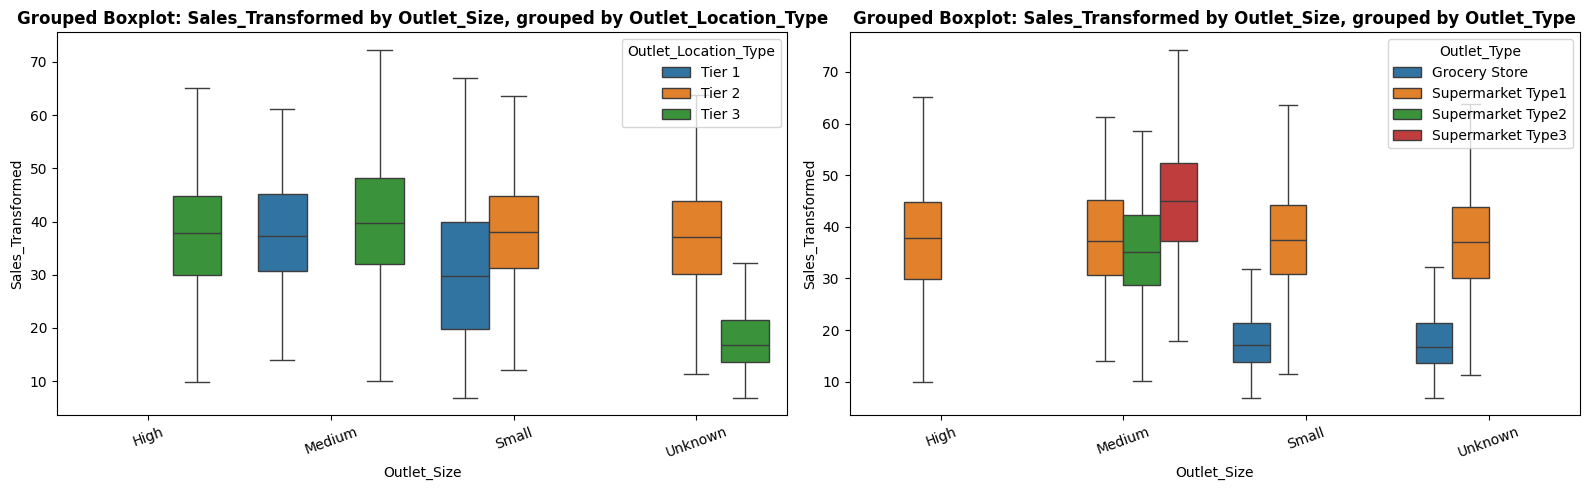

Grouped boxplot inconsistency scores (higher -> stronger interaction signal):


,x_var,hue_var,step_inconsistency_score
1,Outlet_Size,Outlet_Type,0.04893
0,Outlet_Size,Outlet_Location_Type,NaN


In [52]:
# 0.2 Grouped boxplots: inconsistent category steps across sub-groups suggest interaction
def step_inconsistency_score(data, x, hue, target):
    med = data.groupby([x, hue], observed=True)[target].median().unstack(hue)
    med = med.dropna(axis=0, how='all').dropna(axis=1, how='all')
    if med.shape[0] < 2 or med.shape[1] < 2:
        return np.nan

    step_changes = med.diff().iloc[1:]
    if step_changes.empty:
        return np.nan

    row_stds = []
    for _, row in step_changes.iterrows():
        valid_values = row.dropna().values
        if valid_values.size >= 2:
            row_stds.append(float(np.std(valid_values, ddof=0)))

    if not row_stds:
        return np.nan

    return float(np.mean(row_stds))

category_sizes = {c: int(screen_df[c].nunique()) for c in screen_categorical_cols}

if surprising_pair_summary.empty:
    selected_boxplot_pairs = [
        ('Outlet_Size', 'Outlet_Type'),
        ('Outlet_Location_Type', 'Outlet_Type')
    ]
else:
    eligible_pairs = surprising_pair_summary[
        surprising_pair_summary['cat_a'].map(category_sizes).le(6)
        & surprising_pair_summary['cat_b'].map(category_sizes).le(6)
    ].copy()

    if eligible_pairs.empty:
        selected_boxplot_pairs = [
            ('Outlet_Size', 'Outlet_Type'),
            ('Outlet_Location_Type', 'Outlet_Type')
        ]
    else:
        selected_boxplot_pairs = list(
            eligible_pairs[['cat_a', 'cat_b']].head(2).itertuples(index=False, name=None)
        )

fig, axes = plt.subplots(1, len(selected_boxplot_pairs), figsize=(8 * len(selected_boxplot_pairs), 5))
if len(selected_boxplot_pairs) == 1:
    axes = [axes]

grouped_boxplot_scores = []
for ax, (x_var, hue_var) in zip(axes, selected_boxplot_pairs):
    sns.boxplot(
        data=screen_df,
        x=x_var,
        y=target_col,
        hue=hue_var,
        showfliers=False,
        ax=ax
    )
    ax.set_title(f'Grouped Boxplot: {target_col} by {x_var}, grouped by {hue_var}', fontweight='bold')
    ax.tick_params(axis='x', rotation=20)
    grouped_boxplot_scores.append({
        'x_var': x_var,
        'hue_var': hue_var,
        'step_inconsistency_score': step_inconsistency_score(screen_df, x_var, hue_var, target_col)
    })

plt.tight_layout()
plt.show()

grouped_boxplot_scores_df = pd.DataFrame(grouped_boxplot_scores).sort_values(
    'step_inconsistency_score',
    ascending=False
 )

print('Grouped boxplot inconsistency scores (higher -> stronger interaction signal):')
display(grouped_boxplot_scores_df)

## IV. Model Expansion and Parsimonious Pruning
Build interaction models from screened candidates only, enforce hierarchy, and compare against the baseline structure using ANOVA F-tests plus AIC/BIC.

In [53]:
# IV implementation: expand from screened candidates, enforce hierarchy, and prune with ANOVA + AIC/BIC
import numpy as np
import pandas as pd
import statsmodels.formula.api as smf
from statsmodels.stats.anova import anova_lm
from IPython.display import display, Math

def build_formula(target, terms):
    if terms:
        return f"{target} ~ " + " + ".join(terms)
    return f"{target} ~ 1"

def get_type2_pvalue(model, term):
    try:
        tbl = anova_lm(model, typ=2)
    except Exception:
        return np.nan, pd.DataFrame()

    if term in tbl.index:
        return float(tbl.loc[term, 'PR(>F)']), tbl
    return np.nan, tbl

required_objects = [
    'screen_df',
    'target_col',
    'screen_continuous_cols',
    'screen_categorical_cols',
    'cont_cat_resid_scores_df'
 ]
missing_objects = [obj for obj in required_objects if obj not in globals()]
if missing_objects:
    raise RuntimeError(
        'Please run prior cells first. Missing objects: ' + ', '.join(missing_objects)
    )

analysis_df = screen_df.copy()

# Reuse centered predictors created in Step I whenever available.
if 'screen_centered_continuous_cols' in globals() and len(screen_centered_continuous_cols) > 0:
    main_cont_terms = list(screen_centered_continuous_cols)
else:
    centered_map = {}
    for col in screen_continuous_cols:
        centered_col = f'{col}_Centered'
        analysis_df[centered_col] = analysis_df[col] - analysis_df[col].mean()
        centered_map[col] = centered_col
    main_cont_terms = [centered_map[c] for c in screen_continuous_cols]

if 'centered_map' not in globals() or not centered_map:
    centered_map = {c: f'{c}_Centered' for c in screen_continuous_cols}

main_cat_terms = [f'C({c})' for c in screen_categorical_cols]

# Survivors from continuous x continuous screening.
kept_cont_cont = list(globals().get('kept_interactions', []))
kept_cont_cont_centered = []
for term in kept_cont_cont:
    if ':' not in term:
        continue
    left, right = [x.strip() for x in term.split(':', 1)]
    left_centered = centered_map.get(left, f'{left}_Centered')
    right_centered = centered_map.get(right, f'{right}_Centered')
    if left_centered in analysis_df.columns and right_centered in analysis_df.columns:
        kept_cont_cont_centered.append(f"{left_centered}:{right_centered}")
kept_cont_cont_centered = sorted(set(kept_cont_cont_centered))

# Survivors from categorical x categorical screening.
kept_cat_cat_terms = []
if 'significant_interactions_df' in globals() and not significant_interactions_df.empty:
    pair_df = significant_interactions_df[['cat_a', 'cat_b']].drop_duplicates().copy()
    for _, row in pair_df.iterrows():
        kept_cat_cat_terms.append(f"C({row['cat_a']}):C({row['cat_b']})")
kept_cat_cat_terms = sorted(set(kept_cat_cat_terms))

# 1) Formalize top continuous x categorical interactions using Type II ANOVA + AIC.
control_terms = sorted(set(main_cont_terms + main_cat_terms + kept_cont_cont_centered + kept_cat_cat_terms))
control_formula = build_formula(target_col, control_terms)
control_model = smf.ols(control_formula, data=analysis_df).fit()

top_k = min(3, cont_cat_resid_scores_df.shape[0])
top_cont_cat_pairs = cont_cat_resid_scores_df.head(top_k).copy()

formal_cont_cat_rows = []
for _, row in top_cont_cat_pairs.iterrows():
    cont_var = str(row['continuous_var'])
    cat_var = str(row['categorical_var'])

    cont_centered = centered_map.get(cont_var, f'{cont_var}_Centered')
    if cont_centered not in analysis_df.columns:
        cont_centered = cont_var

    test_formula = control_formula + f" + {cont_centered} * C({cat_var})"
    test_model = smf.ols(test_formula, data=analysis_df).fit()

    interaction_term = f"{cont_centered}:C({cat_var})"
    interaction_pvalue, _ = get_type2_pvalue(test_model, interaction_term)
    delta_aic = float(test_model.aic - control_model.aic)

    formal_cont_cat_rows.append({
        'continuous_var': cont_var,
        'categorical_var': cat_var,
        'interaction_term': interaction_term,
        'interaction_p_value': interaction_pvalue,
        'model_aic': float(test_model.aic),
        'delta_aic_vs_control': delta_aic,
        'significant_p_lt_0_05': bool(pd.notna(interaction_pvalue) and interaction_pvalue < 0.05),
        'aic_improved': bool(delta_aic < 0)
    })

formal_cont_cat_results_df = pd.DataFrame(formal_cont_cat_rows)
if formal_cont_cat_results_df.empty:
    kept_cont_cat_terms = []
    print('No continuous x categorical candidates were available for formal testing.')
else:
    formal_cont_cat_results_df = formal_cont_cat_results_df.sort_values(
        ['interaction_p_value', 'delta_aic_vs_control']
    ).reset_index(drop=True)

    kept_cont_cat_terms = formal_cont_cat_results_df.loc[
        formal_cont_cat_results_df['significant_p_lt_0_05'] & formal_cont_cat_results_df['aic_improved'],
        'interaction_term'
    ].tolist()

    print('=== Step IV.A: Formal continuous x categorical interaction tests ===')
    print(f'Control model AIC (without new cont x cat terms): {control_model.aic:.4f}')
    display(formal_cont_cat_results_df)
    print(f'Kept continuous x categorical interactions: {kept_cont_cat_terms if kept_cont_cat_terms else "None"}')

# 2) Build unified interaction model and compare against no-interaction benchmark.
all_interaction_terms = sorted(set(
    kept_cont_cont_centered + kept_cat_cat_terms + kept_cont_cat_terms
))

hierarchy_required_main = set(main_cont_terms + main_cat_terms)
for iterm in all_interaction_terms:
    for part in [x.strip() for x in iterm.split(':')]:
        if part in main_cont_terms or part in main_cat_terms:
            hierarchy_required_main.add(part)

final_main_terms = sorted(hierarchy_required_main)
unified_formula = build_formula(target_col, final_main_terms + all_interaction_terms)
unified_model = smf.ols(unified_formula, data=analysis_df).fit()

no_interaction_formula = build_formula(target_col, final_main_terms)
no_interaction_model = smf.ols(no_interaction_formula, data=analysis_df).fit()

def display_formula_math(title, formula_str):
    safe = str(formula_str).replace('\\', r'\\').replace('_', r'\_').replace('~', r' \sim ')
    print(title)
    display(Math(safe))

print('\n=== Step IV.B: Unified model and benchmark comparison ===')
display_formula_math('Unified formula:', unified_formula)
display_formula_math('No-interaction benchmark formula:', no_interaction_formula)

unified_compare_df = pd.DataFrame([
    {
        'model': 'No-interaction benchmark',
        'AIC': float(no_interaction_model.aic),
        'BIC': float(no_interaction_model.bic),
        'Adj_R2': float(no_interaction_model.rsquared_adj)
    },
    {
        'model': 'Unified interaction model',
        'AIC': float(unified_model.aic),
        'BIC': float(unified_model.bic),
        'Adj_R2': float(unified_model.rsquared_adj)
    }
])
unified_compare_df['Delta_AIC_vs_Benchmark'] = unified_compare_df['AIC'] - no_interaction_model.aic
unified_compare_df['Delta_BIC_vs_Benchmark'] = unified_compare_df['BIC'] - no_interaction_model.bic
display(unified_compare_df)

anova_interaction_gain_df = anova_lm(no_interaction_model, unified_model)
print('ANOVA F-test: no-interaction benchmark vs unified interaction model')
display(anova_interaction_gain_df)

# 3) Interaction significance report inside unified model.
unified_anova_tbl = anova_lm(unified_model, typ=2)
interaction_significance_rows = []
for term in all_interaction_terms:
    p_val = np.nan
    if term in unified_anova_tbl.index:
        p_val = float(unified_anova_tbl.loc[term, 'PR(>F)'])
    interaction_significance_rows.append({
        'interaction_term': term,
        'p_value_in_unified_model': p_val,
        'significant_p_lt_0_05': bool(pd.notna(p_val) and p_val < 0.05)
    })

interaction_significance_df = pd.DataFrame(interaction_significance_rows)
if not interaction_significance_df.empty:
    print('Unified-model interaction significance table:')
    display(interaction_significance_df.sort_values('p_value_in_unified_model').reset_index(drop=True))
else:
    print('Unified model currently has no interaction terms to report.')

=== Step IV.A: Formal continuous x categorical interaction tests ===
Control model AIC (without new cont x cat terms): 45372.3964


,continuous_var,categorical_var,interaction_term,interaction_p_value,model_aic,delta_aic_vs_control,significant_p_lt_0_05,aic_improved
0,Item_Visibility,Outlet_Size,Item_Visibility_Centered:C(Outlet_Size),0.348292,45375.084822,2.688390,False,False
1,Item_Visibility,Outlet_Type,Item_Visibility_Centered:C(Outlet_Type),0.356276,45375.141810,2.745378,False,False
2,Item_Visibility,Item_Type,Item_Visibility_Centered:C(Item_Type),0.779502,45391.721398,19.324966,False,False


Kept continuous x categorical interactions: None

=== Step IV.B: Unified model and benchmark comparison ===
Unified formula:


<IPython.core.display.Math object>

No-interaction benchmark formula:


...

,model,AIC,BIC,Adj_R2,Delta_AIC_vs_Benchmark,Delta_BIC_vs_Benchmark
0,No-interaction benchmark,45395.018963,45593.011285,0.677269,0.00000,0.000000
1,Unified interaction model,45372.396432,45584.043397,0.678432,-22.62253,-8.967888


ANOVA F-test: no-interaction benchmark vs unified interaction model


,df_resid,ssr,df_diff,ss_diff,F,Pr(>F)
0,6789.0,308368.617680,0.0,NaN,NaN,NaN
1,6787.0,307166.865601,2.0,1201.752079,13.276646,0.000002


Unified-model interaction significance table:


,interaction_term,p_value_in_unified_model,significant_p_lt_0_05
0,Item_Visibility_Centered:Item_MRP_Centered,2.789928e-07,True
1,Item_Visibility_Centered:Outlet_Years_Centered,7.127959e-01,False


## IV.5 Selection Summary
This section condenses the screening-to-pruning path so the final interaction structure is transparent before full reliability diagnostics.

- We summarize how many candidates were tested at each stage (continuous x continuous, categorical x categorical, continuous x categorical).
- We report which terms survived significance, AIC checks, and Cook's Distance stability pruning.
- **Principle of Marginality:** if an interaction term is retained, its corresponding main effects are kept in the model even when some main effects are not individually significant.

In [54]:
# IV.5 Selection Summary: concise audit trail from screening -> retained terms
import pandas as pd

# Safe lookups so the summary runs even if some optional branches were skipped.
cc_tested = int(interaction_results_df.shape[0]) if 'interaction_results_df' in globals() else 0
cc_kept = int(len(kept_cont_cont_centered)) if 'kept_cont_cont_centered' in globals() else (
    int(len(kept_interactions)) if 'kept_interactions' in globals() else 0
)

catcat_tested = int(anova_pair_results_df.shape[0]) if 'anova_pair_results_df' in globals() else 0
catcat_kept = int(len(kept_cat_cat_terms)) if 'kept_cat_cat_terms' in globals() else (
    int(len(recovered_anova_cat_cat_terms)) if 'recovered_anova_cat_cat_terms' in globals() else 0
)

contcat_tested = int(formal_cont_cat_results_df.shape[0]) if 'formal_cont_cat_results_df' in globals() else 0
contcat_kept = int(len(kept_cont_cat_terms)) if 'kept_cont_cat_terms' in globals() else 0

if 'all_interaction_terms' in globals():
    pre_pruning_pool = sorted(set(all_interaction_terms))
else:
    pre_pruning_pool = sorted(set(
        (kept_cont_cont_centered if 'kept_cont_cont_centered' in globals() else [])
        + (kept_cat_cat_terms if 'kept_cat_cat_terms' in globals() else [])
        + (kept_cont_cat_terms if 'kept_cont_cat_terms' in globals() else [])
    ))

if 'parsimonious_interactions' in globals():
    final_stable_terms = list(parsimonious_interactions)
elif 'kept_interactions_parsimonious' in globals():
    final_stable_terms = list(kept_interactions_parsimonious)
else:
    final_stable_terms = pre_pruning_pool

selection_audit_df = pd.DataFrame([
    {
        'family': 'Continuous x Continuous',
        'tested': cc_tested,
        'retained_after_screening': cc_kept
    },
    {
        'family': 'Categorical x Categorical (ANOVA)',
        'tested': catcat_tested,
        'retained_after_screening': catcat_kept
    },
    {
        'family': 'Continuous x Categorical',
        'tested': contcat_tested,
        'retained_after_screening': contcat_kept
    }
])

print('Selection audit by term family:')
display(selection_audit_df)

print("\nStable terms after influence-aware pruning (Cook's Distance + significance stability):")
if final_stable_terms:
    final_stable_df = pd.DataFrame({'final_stable_term': final_stable_terms})
    display(final_stable_df)
else:
    print('No interaction terms survived; model remains main-effects only.')

summary_sentence = (
    f'Of {len(pre_pruning_pool)} screened interaction terms, '
    f'{len(final_stable_terms)} remained significant and stable after pruning.'
)
print('\nSelection logic flow summary:')
print(summary_sentence)

# Explicit marginality reminder for interpretability and model hierarchy.
print(
    'Marginality rule applied: all parent main effects are retained whenever an interaction '
    'term is included in the final formula.'
)

Selection audit by term family:


,family,tested,retained_after_screening
0,Continuous x Continuous,6,2
1,Categorical x Categorical (ANOVA),10,0
2,Continuous x Categorical,3,0



Stable terms after influence-aware pruning (Cook's Distance + significance stability):


,final_stable_term
0,Item_Visibility_Centered:Item_MRP_Centered



Selection logic flow summary:
Of 2 screened interaction terms, 1 remained significant and stable after pruning.
Marginality rule applied: all parent main effects are retained whenever an interaction term is included in the final formula.


## V. Statistical Validation and Inference Reliability
After fixing the model structure, evaluate reliability with influence diagnostics (Cook's Distance), multicollinearity (VIF), and residual-variance checks (Breusch-Pagan). If Breusch-Pagan indicates heteroscedasticity, switch inference to HC3 robust standard errors.

In [55]:
# V implementation: influence, multicollinearity, residual variance, and robust inference decision
import numpy as np
import pandas as pd
import statsmodels.formula.api as smf
from statsmodels.stats.anova import anova_lm
from statsmodels.stats.diagnostic import het_breuschpagan
from statsmodels.stats.outliers_influence import variance_inflation_factor
from IPython.display import display, Math

required_for_validation = [
    'analysis_df',
    'target_col',
    'main_cont_terms',
    'main_cat_terms',
    'interaction_significance_df',
    'build_formula',
    'unified_model',
    'unified_formula'
 ]
missing_for_validation = [k for k in required_for_validation if k not in globals()]
if missing_for_validation:
    raise RuntimeError(
        'Run Section IV first. Missing: ' + ', '.join(missing_for_validation)
    )

# ------------------------------------
# A) Finalize interaction pool from Section IV + recover significant ANOVA cat-cat terms
# ------------------------------------
existing_unified_terms = []
if not interaction_significance_df.empty:
    existing_unified_terms = sorted(interaction_significance_df['interaction_term'].dropna().unique().tolist())

significant_unified_terms = []
if not interaction_significance_df.empty:
    significant_unified_terms = sorted(
        interaction_significance_df.loc[
            interaction_significance_df['significant_p_lt_0_05'],
            'interaction_term'
        ].dropna().unique().tolist()
    )

anova_cat_cat_terms = []
if 'anova_pair_results_df' in globals() and not anova_pair_results_df.empty:
    anova_eval_df = anova_pair_results_df.dropna(subset=['p_value']).copy()
    anova_sig_pairs_df = anova_eval_df[anova_eval_df['p_value'] < 0.05].copy()
    anova_sig_pairs_df['interaction_term'] = anova_sig_pairs_df.apply(
        lambda r: f"C({r['cat_a']}):C({r['cat_b']})", axis=1
    )
    anova_cat_cat_terms = sorted(anova_sig_pairs_df['interaction_term'].unique().tolist())

missing_anova_terms = sorted(set(anova_cat_cat_terms) - set(existing_unified_terms))
interaction_pool = sorted(set(significant_unified_terms + anova_cat_cat_terms))

if not interaction_pool and 'all_interaction_terms' in globals():
    interaction_pool = sorted(set(all_interaction_terms))

print('=== Step V.A: Interaction pool entering reliability checks ===')
print(f'Unified significant interactions: {len(significant_unified_terms)}')
print(f'ANOVA significant cat-cat interactions: {len(anova_cat_cat_terms)}')
print(f'Recovered ANOVA terms absent in unified pool: {len(missing_anova_terms)}')
print(f'Interaction pool size for validation: {len(interaction_pool)}')

# Enforce hierarchy for structural model under validation.
structure_main = set(main_cont_terms + main_cat_terms)
for term in interaction_pool:
    for part in [x.strip() for x in term.split(':')]:
        if part in main_cont_terms or part in main_cat_terms:
            structure_main.add(part)
structure_main_terms = sorted(structure_main)

structure_formula = build_formula(target_col, structure_main_terms + interaction_pool)
structure_model = smf.ols(structure_formula, data=analysis_df).fit()
structure_anova = anova_lm(structure_model, typ=2)

# ------------------------------------
# B) Influence sensitivity via Cook's Distance
# ------------------------------------
influence = structure_model.get_influence()
cooks_d = influence.cooks_distance[0]
n_obs = int(structure_model.nobs)
cook_threshold = 4.0 / n_obs

cook_df = pd.DataFrame({
    'obs_index': analysis_df.index.to_numpy(),
    'cooks_d': cooks_d
}).sort_values('cooks_d', ascending=False).reset_index(drop=True)
cook_df['above_4_over_n'] = cook_df['cooks_d'] > cook_threshold

flagged_count = int(cook_df['above_4_over_n'].sum())
remove_count = min(5, max(3, flagged_count), max(1, n_obs - 2))
rows_to_remove = cook_df.head(remove_count)['obs_index'].tolist()

print('\n=== Step V.B: Cook\'s Distance influence check ===')
print(f'n = {n_obs}, threshold 4/n = {cook_threshold:.6f}')
print(f'Rows flagged above threshold: {flagged_count}')
print(f'Refitting sensitivity model after removing top {remove_count} influential rows.')
display(cook_df.head(10))

robust_df = analysis_df.drop(index=rows_to_remove).copy()
structure_model_without_top_influential = smf.ols(structure_formula, data=robust_df).fit()
structure_robust_anova = anova_lm(structure_model_without_top_influential, typ=2)

pruning_rows = []
for term in interaction_pool:
    p_full = np.nan
    p_robust = np.nan
    if term in structure_anova.index:
        p_full = float(structure_anova.loc[term, 'PR(>F)'])
    if term in structure_robust_anova.index:
        p_robust = float(structure_robust_anova.loc[term, 'PR(>F)'])

    sig_flip = False
    if pd.notna(p_full) and pd.notna(p_robust):
        sig_flip = bool((p_full < 0.05) != (p_robust < 0.05))

    p_ratio = np.nan
    if pd.notna(p_full) and pd.notna(p_robust):
        p_ratio = float((p_robust + 1e-12) / (p_full + 1e-12))

    unstable_ratio = bool(pd.notna(p_ratio) and (p_ratio >= 10 or p_ratio <= 0.1))
    significant = bool(pd.notna(p_full) and p_full < 0.05)
    keep_term = bool(significant and (not sig_flip) and (not unstable_ratio))

    if keep_term:
        note = 'Keep'
    elif not significant:
        note = 'Drop: not significant in structural model'
    elif sig_flip:
        note = 'Drop: significance flips after influential-point removal'
    elif unstable_ratio:
        note = 'Drop: unstable p-value ratio after influential-point removal'
    else:
        note = 'Drop'

    pruning_rows.append({
        'interaction_term': term,
        'p_value_full': p_full,
        'p_value_without_top_influential': p_robust,
        'p_ratio_robust_over_full': p_ratio,
        'significance_flip': sig_flip,
        'keep_after_parsimony': keep_term,
        'decision_note': note
    })

parsimony_pruning_df = pd.DataFrame(pruning_rows).sort_values(
    ['keep_after_parsimony', 'p_value_full'], ascending=[False, True]
).reset_index(drop=True)

kept_interactions_parsimonious = parsimony_pruning_df.loc[
    parsimony_pruning_df['keep_after_parsimony'],
    'interaction_term'
].tolist()
dropped_ghost_interactions = parsimony_pruning_df.loc[
    ~parsimony_pruning_df['keep_after_parsimony'],
    'interaction_term'
].tolist()

print('\nParsimony pruning decisions:')
display(parsimony_pruning_df)
print(f'Kept interactions after influence-aware pruning: {len(kept_interactions_parsimonious)}')
print(f'Dropped ghost interactions: {len(dropped_ghost_interactions)}')

# ------------------------------------
# C) Multicollinearity check (VIF) on parsimonious structure
# ------------------------------------
parsimonious_main = set(main_cont_terms + main_cat_terms)
for term in kept_interactions_parsimonious:
    for part in [x.strip() for x in term.split(':')]:
        if part in main_cont_terms or part in main_cat_terms:
            parsimonious_main.add(part)
parsimonious_main_terms = sorted(parsimonious_main)

parsimonious_formula = build_formula(
    target_col,
    parsimonious_main_terms + kept_interactions_parsimonious
)
parsimonious_model = smf.ols(parsimonious_formula, data=analysis_df).fit()

def compute_vif_table(model):
    exog = pd.DataFrame(model.model.exog, columns=model.model.exog_names).copy()
    if 'Intercept' in exog.columns:
        exog = exog.drop(columns=['Intercept'])

    vif_rows = []
    for idx, col_name in enumerate(exog.columns):
        vif_rows.append({
            'term': col_name,
            'VIF': float(variance_inflation_factor(exog.values, idx))
        })

    return pd.DataFrame(vif_rows).sort_values('VIF', ascending=False).reset_index(drop=True)

final_vif_df = compute_vif_table(parsimonious_model)
print('\n=== Step V.C: VIF table on parsimonious structure ===')
display(final_vif_df.head(20))

# ------------------------------------
# D) Breusch-Pagan and robust standard errors decision
# ------------------------------------
bp_pars = het_breuschpagan(parsimonious_model.resid, parsimonious_model.model.exog)
bp_lm_p_value = float(bp_pars[1])
bp_f_p_value = float(bp_pars[3])
bp_requires_robust_se = bool(bp_lm_p_value < 0.05)

if bp_requires_robust_se:
    final_refined_model = smf.ols(parsimonious_formula, data=analysis_df).fit(cov_type='HC3')
    final_inference_mode = 'HC3 robust standard errors (Breusch-Pagan indicated heteroscedasticity)'
else:
    final_refined_model = parsimonious_model
    final_inference_mode = 'OLS standard errors (Breusch-Pagan did not indicate heteroscedasticity)'

final_refined_formula = parsimonious_formula

print('\n=== Step V.D: Breusch-Pagan decision ===')
print(f'BP LM p-value: {bp_lm_p_value:.6f}')
print(f'BP F p-value: {bp_f_p_value:.6f}')
print(f'Inference mode selected: {final_inference_mode}')

# Model-level comparison for transparency.
no_interaction_ref_formula = build_formula(target_col, sorted(set(main_cont_terms + main_cat_terms)))
no_interaction_ref_model = smf.ols(no_interaction_ref_formula, data=analysis_df).fit()

refinement_compare_df = pd.DataFrame([
    {
        'model': 'No-interaction benchmark',
        'AIC': float(no_interaction_ref_model.aic),
        'BIC': float(no_interaction_ref_model.bic),
        'Adj_R2': float(no_interaction_ref_model.rsquared_adj)
    },
    {
        'model': 'Unified interaction model',
        'AIC': float(unified_model.aic),
        'BIC': float(unified_model.bic),
        'Adj_R2': float(unified_model.rsquared_adj)
    },
    {
        'model': 'Final Parsimonious Model (Used for Inference)',
        'AIC': float(parsimonious_model.aic),
        'BIC': float(parsimonious_model.bic),
        'Adj_R2': float(parsimonious_model.rsquared_adj)
    }
])
refinement_compare_df['Delta_AIC_vs_Final'] = refinement_compare_df['AIC'] - parsimonious_model.aic
refinement_compare_df['Delta_BIC_vs_Final'] = refinement_compare_df['BIC'] - parsimonious_model.bic
print('\nModel comparison (AIC/BIC parsimony lens):')
display(refinement_compare_df.sort_values('AIC').reset_index(drop=True))

funnel_pars = np.corrcoef(parsimonious_model.fittedvalues, np.abs(parsimonious_model.resid))[0, 1]
bp_final = het_breuschpagan(final_refined_model.resid, final_refined_model.model.exog)
funnel_final = np.corrcoef(final_refined_model.fittedvalues, np.abs(final_refined_model.resid))[0, 1]

validation_diag_df = pd.DataFrame([
    {
        'model': 'Parsimonious structure (OLS fit)',
        'funnel_corr_abs_resid_vs_fitted': float(funnel_pars),
        'BP_LM_p_value': float(bp_pars[1]),
        'BP_F_p_value': float(bp_pars[3])
    },
    {
        'model': 'Final model used for inference',
        'funnel_corr_abs_resid_vs_fitted': float(funnel_final),
        'BP_LM_p_value': float(bp_final[1]),
        'BP_F_p_value': float(bp_final[3])
    }
])
validation_diag_df['heteroscedasticity_flag_alpha_0_05'] = np.where(
    validation_diag_df['BP_LM_p_value'] < 0.05,
    'Likely present (use robust inference)',
    'Not detected (OLS inference acceptable)'
)
print('Residual-variance diagnostics:')
display(validation_diag_df)

# Export final artifacts for downstream section.
recovered_anova_cat_cat_terms = anova_cat_cat_terms
missing_anova_terms_in_unified = missing_anova_terms
parsimonious_interactions = kept_interactions_parsimonious
ghost_interactions_removed = dropped_ghost_interactions

def display_formula_math(title, formula_str):
    safe = str(formula_str).replace('\\', r'\\').replace('_', r'\_').replace('~', r' \sim ')
    print(title)
    display(Math(safe))

display_formula_math('Final refined formula used in Section V.1:', final_refined_formula)

=== Step V.A: Interaction pool entering reliability checks ===
Unified significant interactions: 1
ANOVA significant cat-cat interactions: 0
Recovered ANOVA terms absent in unified pool: 0
Interaction pool size for validation: 1

=== Step V.B: Cook's Distance influence check ===
n = 6818, threshold 4/n = 0.000587
Rows flagged above threshold: 323
Refitting sensitivity model after removing top 5 influential rows.


,obs_index,cooks_d,above_4_over_n
0,4432,0.005160,True
1,2100,0.003760,True
2,5165,0.003582,True
3,2139,0.003383,True
4,3772,0.003237,True
5,3404,0.003072,True
6,3720,0.002603,True
7,1939,0.002494,True
8,3768,0.002469,True
9,5600,0.002444,True



Parsimony pruning decisions:


,interaction_term,p_value_full,p_value_without_top_influential,p_ratio_robust_over_full,significance_flip,keep_after_parsimony,decision_note
0,Item_Visibility_Centered:Item_MRP_Centered,2.821891e-07,3.243717e-07,1.149483,False,True,Keep


Kept interactions after influence-aware pruning: 1
Dropped ghost interactions: 0


...

,model,AIC,BIC,Adj_R2,Delta_AIC_vs_Final,Delta_BIC_vs_Final
0,Final Parsimonious Model (Used for Inference),45370.532561,45575.352205,0.678473,0.000000,0.000000
1,Unified interaction model,45372.396432,45584.043397,0.678432,1.863871,8.691192
2,No-interaction benchmark,45395.018963,45593.011285,0.677269,24.486401,17.659080


Residual-variance diagnostics:


,model,funnel_corr_abs_resid_vs_fitted,BP_LM_p_value,BP_F_p_value,heteroscedasticity_flag_alpha_0_05
0,Parsimonious structure (OLS fit),0.216292,1.177636e-59,4.304828e-62,Likely present (use robust inference)
1,Final model used for inference,0.216292,1.177636e-59,4.304828e-62,Likely present (use robust inference)


Final refined formula used in Section V.1:


<IPython.core.display.Math object>

### V.1 Final Before-vs-After Residual Diagnostics and Breusch-Pagan Comparison
Compare baseline (main effects only) against the final refined interaction model to verify whether variance behavior improved and whether robust inference is required.

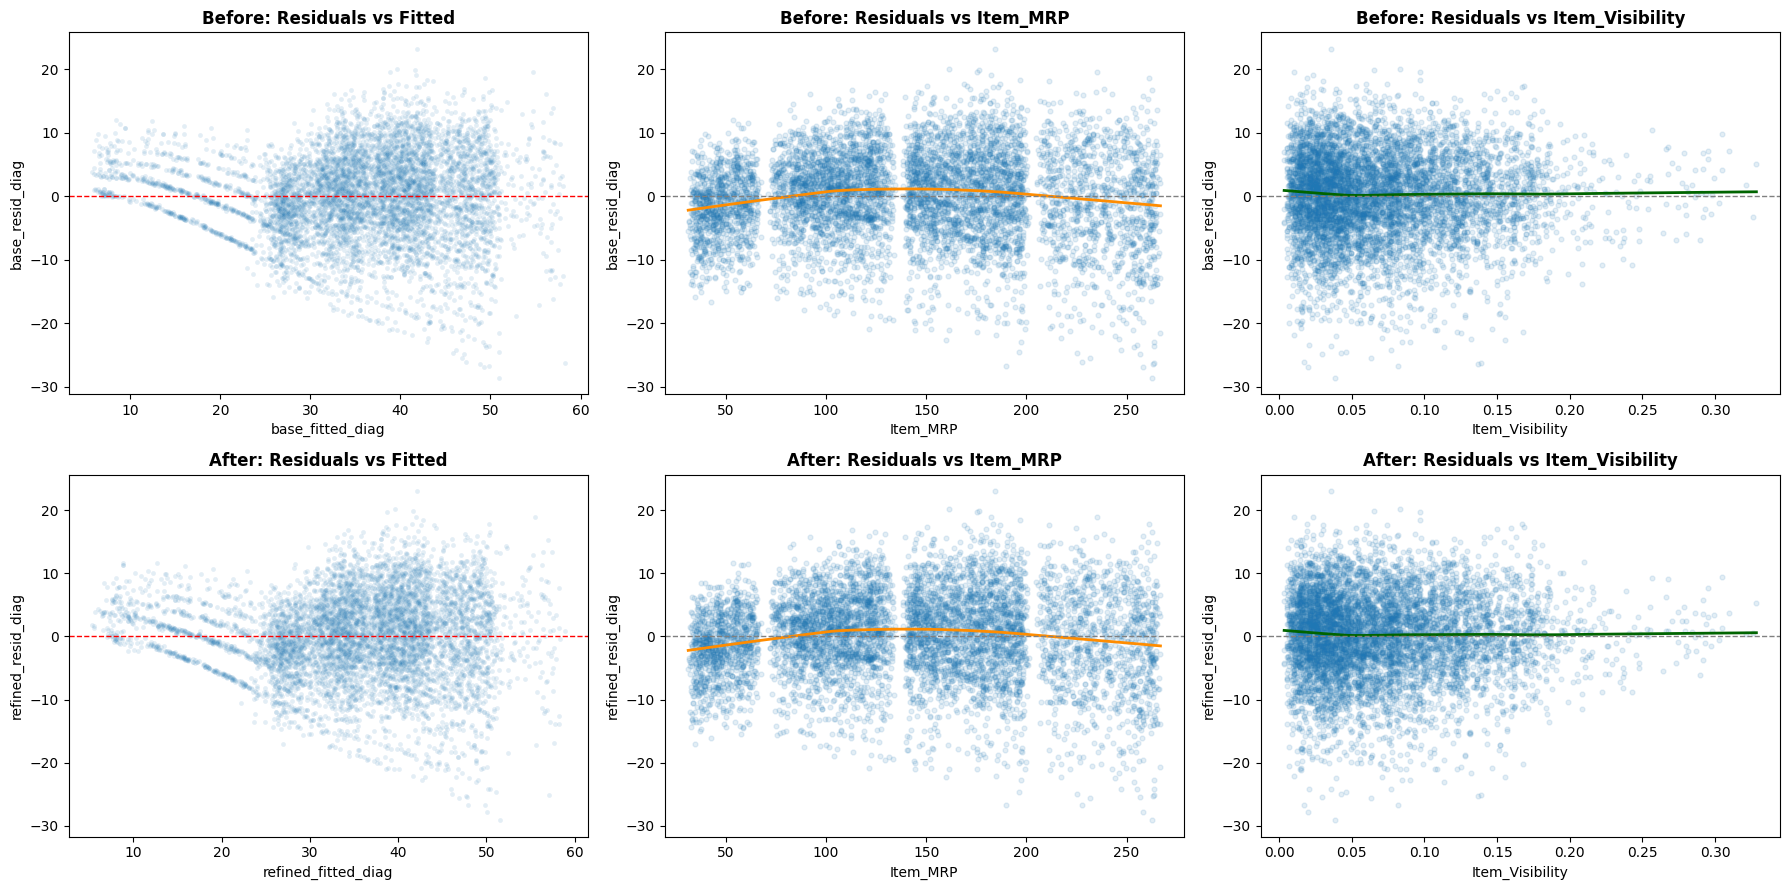


=== Final Residual Funnel Proxy (corr(|resid|, fitted)) ===
Before interactions (main effects only): 0.2083
After (final validated interaction model): 0.2163

Breusch-Pagan test comparison:


,model,LM_stat,LM_p_value,F_stat,F_p_value,heteroscedasticity_flag_alpha_0_05
0,Before interactions (main effects only),349.262057,1.254870e-56,13.091205,7.094498e-59,Likely present (reject homoscedasticity)
1,After interactions (final validated model),367.103178,1.177636e-59,13.320235,4.304828e-62,Likely present (reject homoscedasticity)


Inference mode currently used: HC3 robust standard errors (Breusch-Pagan indicated heteroscedasticity)


In [56]:
# ------------------------------
# V.1 Final residual diagnostics + Breusch-Pagan before vs after
# ------------------------------
baseline_compare_cont = list(globals().get('main_cont_terms', []))
if not baseline_compare_cont:
    baseline_compare_cont = list(globals().get('screen_centered_continuous_cols', screen_continuous_cols))

base_compare_formula = build_formula(
    target_col,
    baseline_compare_cont + [f'C({c})' for c in screen_categorical_cols]
 )
base_compare_model = smf.ols(base_compare_formula, data=analysis_df).fit()

diag_df = analysis_df.copy()
diag_df['base_fitted_diag'] = base_compare_model.fittedvalues
diag_df['base_resid_diag'] = base_compare_model.resid
diag_df['refined_fitted_diag'] = final_refined_model.fittedvalues
diag_df['refined_resid_diag'] = final_refined_model.resid

fig, axes = plt.subplots(2, 3, figsize=(18, 9))

sns.scatterplot(
    data=diag_df,
    x='base_fitted_diag',
    y='base_resid_diag',
    alpha=0.12,
    s=12,
    ax=axes[0, 0]
 )
axes[0, 0].axhline(0, color='red', linestyle='--', linewidth=1)
axes[0, 0].set_title('Before: Residuals vs Fitted', fontweight='bold')

sns.regplot(
    data=diag_df,
    x='Item_MRP',
    y='base_resid_diag',
    lowess=True,
    scatter_kws={'alpha': 0.12, 's': 12},
    line_kws={'color': 'darkorange', 'linewidth': 2},
    ax=axes[0, 1]
 )
axes[0, 1].axhline(0, color='gray', linestyle='--', linewidth=1)
axes[0, 1].set_title('Before: Residuals vs Item_MRP', fontweight='bold')

sns.regplot(
    data=diag_df,
    x='Item_Visibility',
    y='base_resid_diag',
    lowess=True,
    scatter_kws={'alpha': 0.12, 's': 12},
    line_kws={'color': 'darkgreen', 'linewidth': 2},
    ax=axes[0, 2]
 )
axes[0, 2].axhline(0, color='gray', linestyle='--', linewidth=1)
axes[0, 2].set_title('Before: Residuals vs Item_Visibility', fontweight='bold')

sns.scatterplot(
    data=diag_df,
    x='refined_fitted_diag',
    y='refined_resid_diag',
    alpha=0.12,
    s=12,
    ax=axes[1, 0]
 )
axes[1, 0].axhline(0, color='red', linestyle='--', linewidth=1)
axes[1, 0].set_title('After: Residuals vs Fitted', fontweight='bold')

sns.regplot(
    data=diag_df,
    x='Item_MRP',
    y='refined_resid_diag',
    lowess=True,
    scatter_kws={'alpha': 0.12, 's': 12},
    line_kws={'color': 'darkorange', 'linewidth': 2},
    ax=axes[1, 1]
 )
axes[1, 1].axhline(0, color='gray', linestyle='--', linewidth=1)
axes[1, 1].set_title('After: Residuals vs Item_MRP', fontweight='bold')

sns.regplot(
    data=diag_df,
    x='Item_Visibility',
    y='refined_resid_diag',
    lowess=True,
    scatter_kws={'alpha': 0.12, 's': 12},
    line_kws={'color': 'darkgreen', 'linewidth': 2},
    ax=axes[1, 2]
 )
axes[1, 2].axhline(0, color='gray', linestyle='--', linewidth=1)
axes[1, 2].set_title('After: Residuals vs Item_Visibility', fontweight='bold')

plt.tight_layout()
plt.show()

before_funnel_corr = np.corrcoef(diag_df['base_fitted_diag'], np.abs(diag_df['base_resid_diag']))[0, 1]
after_funnel_corr = np.corrcoef(diag_df['refined_fitted_diag'], np.abs(diag_df['refined_resid_diag']))[0, 1]
print('\n=== Final Residual Funnel Proxy (corr(|resid|, fitted)) ===')
print(f'Before interactions (main effects only): {before_funnel_corr:.4f}')
print(f'After (final validated interaction model): {after_funnel_corr:.4f}')

bp_before = het_breuschpagan(base_compare_model.resid, base_compare_model.model.exog)
bp_after = het_breuschpagan(final_refined_model.resid, final_refined_model.model.exog)

bp_results_df = pd.DataFrame([
    {
        'model': 'Before interactions (main effects only)',
        'LM_stat': float(bp_before[0]),
        'LM_p_value': float(bp_before[1]),
        'F_stat': float(bp_before[2]),
        'F_p_value': float(bp_before[3])
    },
    {
        'model': 'After interactions (final validated model)',
        'LM_stat': float(bp_after[0]),
        'LM_p_value': float(bp_after[1]),
        'F_stat': float(bp_after[2]),
        'F_p_value': float(bp_after[3])
    }
])

bp_results_df['heteroscedasticity_flag_alpha_0_05'] = np.where(
    bp_results_df['LM_p_value'] < 0.05,
    'Likely present (reject homoscedasticity)',
    'Not detected (fail to reject homoscedasticity)'
 )

print('\nBreusch-Pagan test comparison:')
display(bp_results_df)

if 'final_inference_mode' in globals():
    print(f'Inference mode currently used: {final_inference_mode}')

### V.2 Executive Result: Final Parsimonious Model
This is the final model result for interpretation after structure selection, influence pruning, multicollinearity checks, and Breusch-Pagan decision.

- The coefficient table below reports **coefficient**, **standard error** (HC3 robust if selected), and **p-value**.
- The second table compares baseline main-effects fit vs the final interaction model fit to show whether complexity delivered measurable gain.

In [57]:
# V.2 Executive Result: compact final table 
import pandas as pd
import statsmodels.formula.api as smf
from IPython.display import display, Math

if 'final_refined_formula' not in globals() or 'analysis_df' not in globals():
    raise RuntimeError('Run Section V first so final_refined_formula and analysis_df are available.')

# Ensure we have a model object aligned with final_refined_formula.
if 'final_refined_model' not in globals() or final_refined_model.model.formula != final_refined_formula:
    final_refined_model = smf.ols(final_refined_formula, data=analysis_df).fit(cov_type='HC3')

se_mode = 'HC3 robust SE' if ('HC3' in str(getattr(final_refined_model, 'cov_type', '')).upper()) else 'OLS SE'

final_exec_coef_df = pd.DataFrame({
    'term': final_refined_model.params.index,
    'coefficient': final_refined_model.params.values,
    'std_error': final_refined_model.bse.values,
    'p_value': final_refined_model.pvalues.values
}).sort_values('p_value').reset_index(drop=True)

def display_formula_math(title, formula_str):
    safe = str(formula_str).replace('\\', r'\\').replace('_', r'\_').replace('~', r' \sim ')
    print(title)
    display(Math(safe))

display_formula_math('Final formula used for executive report:', final_refined_formula)
print(f'Standard error mode: {se_mode}')
print('\nFinal parsimonious model coefficients:')
display(final_exec_coef_df)

# Keep baseline/full fit artifacts for the final consolidated comparison section.
baseline_main_terms = sorted(set(main_cont_terms + main_cat_terms)) if 'main_cont_terms' in globals() else []
if not baseline_main_terms:
    raise RuntimeError('main_cont_terms/main_cat_terms not found. Run Section IV before this summary.')

baseline_exec_formula = build_formula(target_col, baseline_main_terms)
baseline_exec_model = smf.ols(baseline_exec_formula, data=analysis_df).fit()
interaction_exec_model = final_refined_model

fit_compare_stage_v2_df = pd.DataFrame([
    {
        'model': 'Baseline (main effects only)',
        'R_squared': float(baseline_exec_model.rsquared),
        'Adj_R_squared': float(baseline_exec_model.rsquared_adj)
    },
    {
        'model': 'Full interaction model',
        'R_squared': float(interaction_exec_model.rsquared),
        'Adj_R_squared': float(interaction_exec_model.rsquared_adj)
    }
])

exec_baseline_r2 = float(baseline_exec_model.rsquared)
exec_final_r2 = float(interaction_exec_model.rsquared)
print('\nFit comparison is deferred to the final consolidated section at the end of this notebook.')

Final formula used for executive report:


<IPython.core.display.Math object>

Standard error mode: HC3 robust SE

Final parsimonious model coefficients:


,term,coefficient,std_error,p_value
0,Item_MRP_Centered,0.105397,0.001372,0.000000e+00
1,C(Outlet_Type)[T.Supermarket Type3],28.130600,1.198618,8.420188e-122
2,C(Outlet_Type)[T.Supermarket Type1],17.151155,0.940412,2.581536e-74
3,C(Outlet_Type)[T.Supermarket Type2],14.460386,0.910014,7.399360e-57
4,Intercept,23.395751,2.657405,1.320420e-18
5,Item_Visibility_Centered:Item_MRP_Centered,-0.135507,0.025699,1.342582e-07
6,C(Outlet_Size)[T.Unknown],-4.350924,1.730995,1.195262e-02
7,Outlet_Years_Centered,-0.157418,0.072046,2.889142e-02
8,C(Outlet_Size)[T.Small],-3.491151,1.720754,4.247355e-02
9,C(Item_Type)[T.Dairy],-0.827798,0.416038,4.662194e-02



Fit comparison is deferred to the final consolidated section at the end of this notebook.


### V.3 Visual Interpretation of Key Interaction
We now translate the `Item_Visibility_Centered : Item_MRP_Centered` result from a p-value into a visual slope comparison.

Because predictors were centered, each main-effect coefficient is interpreted at the **average value of the other continuous predictors** (where centered covariates equal 0). This makes the interaction slope differences easier to interpret.

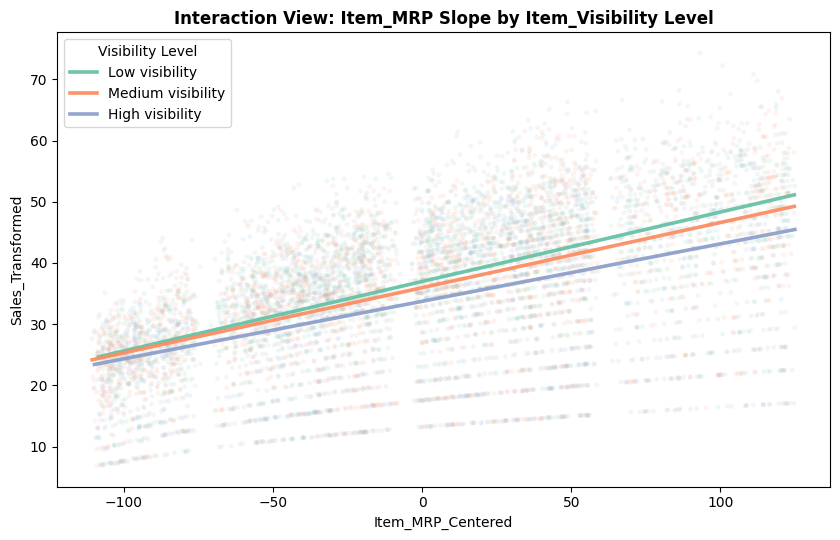

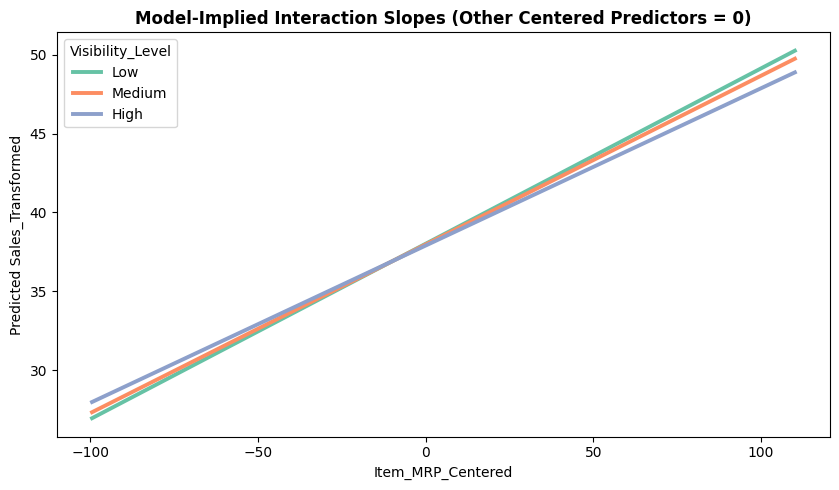

Key interpretation: non-parallel lines are consistent with a retained Item_Visibility x Item_MRP interaction.


In [58]:
# V.3 Interaction plot: how Item_MRP slope changes across Item_Visibility levels
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

if 'analysis_df' not in globals():
    raise RuntimeError('analysis_df not found. Run previous sections first.')

viz_df = analysis_df.copy()

# Ensure centered columns exist for interpretability-focused plotting.
if 'Item_MRP_Centered' not in viz_df.columns and 'Item_MRP' in viz_df.columns:
    viz_df['Item_MRP_Centered'] = viz_df['Item_MRP'] - viz_df['Item_MRP'].mean()
if 'Item_Visibility_Centered' not in viz_df.columns and 'Item_Visibility' in viz_df.columns:
    viz_df['Item_Visibility_Centered'] = viz_df['Item_Visibility'] - viz_df['Item_Visibility'].mean()

required_cols = ['Item_MRP_Centered', 'Item_Visibility_Centered', target_col]
missing_cols = [c for c in required_cols if c not in viz_df.columns]
if missing_cols:
    raise RuntimeError('Missing columns for interaction visualization: ' + ', '.join(missing_cols))

# Bin centered visibility into low/medium/high groups for slope comparison.
viz_df = viz_df.dropna(subset=required_cols).copy()
viz_df['Visibility_Level'] = pd.qcut(
    viz_df['Item_Visibility_Centered'],
    q=3,
    labels=['Low', 'Medium', 'High'],
    duplicates='drop'
)

# 1) Data-level slope evidence: non-parallel fitted lines suggest interaction.
plt.figure(figsize=(8.5, 5.5))
sns.scatterplot(
    data=viz_df,
    x='Item_MRP_Centered',
    y=target_col,
    hue='Visibility_Level',
    alpha=0.10,
    s=12,
    palette='Set2',
    legend=False
)

for level, color in [('Low', '#66c2a5'), ('Medium', '#fc8d62'), ('High', '#8da0cb')]:
    grp = viz_df[viz_df['Visibility_Level'] == level]
    if grp.shape[0] >= 30 and grp['Item_MRP_Centered'].nunique() > 2:
        sns.regplot(
            data=grp,
            x='Item_MRP_Centered',
            y=target_col,
            scatter=False,
            ci=None,
            line_kws={'linewidth': 2.6, 'alpha': 0.95},
            color=color,
            label=f'{level} visibility'
        )

plt.title('Interaction View: Item_MRP Slope by Item_Visibility Level', fontweight='bold')
plt.xlabel('Item_MRP_Centered')
plt.ylabel(target_col)
plt.legend(title='Visibility Level')
plt.tight_layout()
plt.show()

# 2) Model-based predicted lines (holding other centered continuous predictors at 0).
if 'final_refined_model' in globals():
    # Choose representative centered visibility values from quantiles.
    vis_quantiles = viz_df['Item_Visibility_Centered'].quantile([0.2, 0.5, 0.8]).to_dict()
    level_to_vis = {'Low': vis_quantiles[0.2], 'Medium': vis_quantiles[0.5], 'High': vis_quantiles[0.8]}

    mrp_grid = np.linspace(
        viz_df['Item_MRP_Centered'].quantile(0.05),
        viz_df['Item_MRP_Centered'].quantile(0.95),
        80
    )

    pred_frames = []
    for level, vis_val in level_to_vis.items():
        row_df = pd.DataFrame({'Item_MRP_Centered': mrp_grid, 'Item_Visibility_Centered': vis_val})

        # Hold remaining centered continuous variables at their means (0 after centering).
        for col in [c for c in main_cont_terms if c not in row_df.columns]:
            row_df[col] = 0.0

        # Hold categoricals at reference (first observed category) for clean slope comparison.
        for cat in screen_categorical_cols:
            if cat in viz_df.columns:
                ref_series = viz_df[cat].dropna().astype(str)
                row_df[cat] = ref_series.iloc[0] if ref_series.shape[0] > 0 else None

        row_df[target_col] = final_refined_model.predict(row_df)
        row_df['Visibility_Level'] = level
        pred_frames.append(row_df[['Item_MRP_Centered', target_col, 'Visibility_Level']])

    pred_plot_df = pd.concat(pred_frames, ignore_index=True)

    plt.figure(figsize=(8.5, 5.0))
    sns.lineplot(
        data=pred_plot_df,
        x='Item_MRP_Centered',
        y=target_col,
        hue='Visibility_Level',
        palette='Set2',
        linewidth=2.8
    )
    plt.title('Model-Implied Interaction Slopes (Other Centered Predictors = 0)', fontweight='bold')
    plt.xlabel('Item_MRP_Centered')
    plt.ylabel(f'Predicted {target_col}')
    plt.tight_layout()
    plt.show()

interaction_in_formula = ('Item_Visibility_Centered:Item_MRP_Centered' in final_refined_formula) or ('Item_MRP_Centered:Item_Visibility_Centered' in final_refined_formula)
if interaction_in_formula:
    print('Key interpretation: non-parallel lines are consistent with a retained Item_Visibility x Item_MRP interaction.')
else:
    print('Note: Item_Visibility x Item_MRP was not explicitly retained in the final formula; plot shown for interpretive context.')

In [59]:
# VI. Train on train_data, test on test_data with final refined formula (LaTeX + coefficients)
import re
import numpy as np
import pandas as pd
import statsmodels.formula.api as smf
from IPython.display import display, Math
from scipy.stats import boxcox
from scipy.special import inv_boxcox

if 'final_refined_formula' not in globals():
    raise RuntimeError("`final_refined_formula` is not defined. Run Section V first.")

# Load explicit train/test files as requested
train_eval_df = pd.read_csv('../data/train_data/train.csv').copy()
test_eval_df = pd.read_csv('../data/test_data/test.csv').copy()

# Core variables used by this notebook workflow
continuous_cols = list(globals().get('screen_continuous_cols', ['Item_Weight', 'Item_Visibility', 'Item_MRP', 'Outlet_Years']))
categorical_cols = list(globals().get('screen_categorical_cols', [
    'Item_Fat_Content', 'Item_Type', 'Outlet_Size', 'Outlet_Location_Type', 'Outlet_Type'
 ]))

# Match training-time Box-Cox setup
optimal_lambda_eval = float(globals().get('optimal_lambda', 0.346765))
target_raw_col = 'Item_Outlet_Sales'
target_trans_col = 'Sales_Transformed'

if target_raw_col not in train_eval_df.columns:
    raise KeyError(f"{target_raw_col} is missing in train_data.")
if train_eval_df[target_raw_col].min() <= 0:
    raise ValueError('Item_Outlet_Sales in train_data must be strictly positive for Box-Cox transformation.')

train_eval_df[target_trans_col] = boxcox(train_eval_df[target_raw_col], lmbda=optimal_lambda_eval)

# Build centered predictors using train means, then apply same means to test
train_means = {}
for col in continuous_cols:
    center_col = f'{col}_Centered'
    mu = float(train_eval_df[col].mean())
    train_means[col] = mu
    train_eval_df[center_col] = train_eval_df[col] - mu
    if col in test_eval_df.columns:
        test_eval_df[center_col] = test_eval_df[col] - mu

# Align categorical dtypes between train and test
for col in categorical_cols:
    if col in train_eval_df.columns:
        train_eval_df[col] = train_eval_df[col].astype('category')
    if col in test_eval_df.columns and col in train_eval_df.columns:
        test_eval_df[col] = pd.Categorical(test_eval_df[col], categories=train_eval_df[col].cat.categories)

# Fit full interaction formula on train_data
train_test_model = smf.ols(final_refined_formula, data=train_eval_df).fit(cov_type='HC3')

# --- Render final formula as display LaTeX ---
def _escape_latex_var(name: str) -> str:
    return name.replace('_', r'\_')

def _patsy_term_to_latex(term: str) -> str:
    term = term.strip()
    if term.startswith('C(') and term.endswith(')'):
        var = term[2:-1].strip()
        return rf'\mathrm{{{_escape_latex_var(var)}}}'
    if term.startswith('I(') and term.endswith(')') and '** 2' in term:
        inner = term[2:-1].replace('** 2', '').strip()
        return rf'\left(\mathrm{{{_escape_latex_var(inner)}}}\right)^2'
    if ':' in term:
        parts = [p.strip() for p in term.split(':')]
        return ' \\times '.join(_patsy_term_to_latex(p) for p in parts)
    return rf'\mathrm{{{_escape_latex_var(term)}}}'

lhs, rhs = [x.strip() for x in final_refined_formula.split('~', 1)]
rhs_terms = [t.strip() for t in rhs.split('+')]
rhs_latex = ' + '.join(_patsy_term_to_latex(t) for t in rhs_terms)
formula_latex = rf'\mathrm{{{_escape_latex_var(lhs)}}} = \beta_0 + {rhs_latex}'

print('Final refined formula (display LaTeX):')
display(Math(formula_latex))

# Estimated coefficients
coef_df = (
    pd.DataFrame({
        'term': train_test_model.params.index,
        'coef_estimate': train_test_model.params.values,
        'std_error': train_test_model.bse.values,
        'z_or_t_stat': train_test_model.tvalues.values,
        'p_value': train_test_model.pvalues.values
    })
    .sort_values('p_value')
    .reset_index(drop=True)
)

print('\nEstimated coefficients from train_data fit:')
display(coef_df)

# Predict on test_data (store artifacts; final display is deferred to end summary)
test_eval_df = test_eval_df.copy()
if target_raw_col in test_eval_df.columns:
    test_eval_df[target_trans_col] = boxcox(test_eval_df[target_raw_col], lmbda=optimal_lambda_eval)

test_eval_df['Pred_Sales_Transformed'] = train_test_model.predict(test_eval_df)
test_eval_df['Pred_Item_Outlet_Sales'] = inv_boxcox(test_eval_df['Pred_Sales_Transformed'], optimal_lambda_eval)

preview_cols = [c for c in [target_raw_col, 'Pred_Item_Outlet_Sales', target_trans_col, 'Pred_Sales_Transformed'] if c in test_eval_df.columns]
full_model_test_preview_df = test_eval_df[preview_cols].head(10).copy()

def _rmse(y_true, y_pred):
    return float(np.sqrt(np.mean((y_true - y_pred) ** 2)))

def _mae(y_true, y_pred):
    return float(np.mean(np.abs(y_true - y_pred)))

def _r2(y_true, y_pred):
    ss_res = float(np.sum((y_true - y_pred) ** 2))
    ss_tot = float(np.sum((y_true - np.mean(y_true)) ** 2))
    if np.isclose(ss_tot, 0.0):
        return np.nan
    return float(1.0 - ss_res / ss_tot)

full_model_test_metrics_df = pd.DataFrame()
# If test_data has the true target, compute metrics and store for final section
if target_raw_col in test_eval_df.columns:
    valid_eval = test_eval_df[[target_raw_col, 'Pred_Item_Outlet_Sales', 'Pred_Sales_Transformed']].dropna().copy()
    if not valid_eval.empty:
        y_true_orig = valid_eval[target_raw_col].to_numpy(dtype=float)
        y_pred_orig = valid_eval['Pred_Item_Outlet_Sales'].to_numpy(dtype=float)

        rmse_orig = _rmse(y_true_orig, y_pred_orig)
        mae_orig = _mae(y_true_orig, y_pred_orig)
        r2_orig = _r2(y_true_orig, y_pred_orig)

        true_trans = boxcox(valid_eval[target_raw_col], lmbda=optimal_lambda_eval)
        y_true_trans = np.asarray(true_trans, dtype=float)
        y_pred_trans = valid_eval['Pred_Sales_Transformed'].to_numpy(dtype=float)

        rmse_trans = _rmse(y_true_trans, y_pred_trans)
        mae_trans = _mae(y_true_trans, y_pred_trans)
        r2_trans = _r2(y_true_trans, y_pred_trans)

        full_model_test_metrics_df = pd.DataFrame([
            {'model': 'Full interaction model', 'scale': 'Original Item_Outlet_Sales', 'RMSE': rmse_orig, 'MAE': mae_orig, 'R2': r2_orig},
            {'model': 'Full interaction model', 'scale': 'Box-Cox Sales_Transformed', 'RMSE': rmse_trans, 'MAE': mae_trans, 'R2': r2_trans}
        ])

print('\nStored full-model test predictions/metrics for the final consolidated section at the end of this notebook.')
print(f'Fitted on train_data rows: {train_eval_df.shape[0]}')
print(f'Tested on test_data rows: {test_eval_df.shape[0]}')

Final refined formula (display LaTeX):


<IPython.core.display.Math object>


Estimated coefficients from train_data fit:


,term,coef_estimate,std_error,z_or_t_stat,p_value
0,Item_MRP_Centered,0.105397,0.001372,76.826696,0.000000e+00
1,C(Outlet_Type)[T.Supermarket Type3],28.130600,1.198618,23.469191,8.420188e-122
2,C(Outlet_Type)[T.Supermarket Type1],17.151155,0.940412,18.237907,2.581536e-74
3,C(Outlet_Type)[T.Supermarket Type2],14.460386,0.910014,15.890282,7.399360e-57
4,Intercept,23.395751,2.657405,8.803985,1.320420e-18
5,Item_Visibility_Centered:Item_MRP_Centered,-0.135507,0.025699,-5.272936,1.342582e-07
6,C(Outlet_Size)[T.Unknown],-4.350924,1.730995,-2.513540,1.195262e-02
7,Outlet_Years_Centered,-0.157418,0.072046,-2.184965,2.889142e-02
8,C(Outlet_Size)[T.Small],-3.491151,1.720754,-2.028850,4.247355e-02
9,C(Item_Type)[T.Dairy],-0.827798,0.416038,-1.989719,4.662194e-02



Stored full-model test predictions/metrics for the final consolidated section at the end of this notebook.
Fitted on train_data rows: 6818
Tested on test_data rows: 1705


In [60]:
# VI.1 Compact coefficient table display (Markdown Table Output)
from IPython.display import display, Markdown

# Create tabular data as DataFrame first for sorting
coef_table_df = pd.DataFrame({
    'Predictor Term': train_test_model.params.index,
    'Estimate': train_test_model.params.values,
    'Std.Error': train_test_model.bse.values,
    'p-value': train_test_model.pvalues.values
}).sort_values('p-value').reset_index(drop=True)

# Build Markdown Table manually to avoid 'tabulate' dependency
md_header = "| Predictor Term | Estimate | Std.Error | p-value |\n| :--- | :--- | :--- | :--- |\n"
md_rows = []
for _, row in coef_table_df.iterrows():
    p_fmt = f"{row['p-value']:.4e}" if row['p-value'] < 0.001 else f"{row['p-value']:.4f}"
    md_rows.append(f"| {row['Predictor Term']} | {row['Estimate']:.6f} | {row['Std.Error']:.6f} | {p_fmt} |")

md_table = "### Final Model Estimated Coefficients\n\n" + md_header + "\n".join(md_rows)
display(Markdown(md_table))

### Final Model Estimated Coefficients

| Predictor Term | Estimate | Std.Error | p-value |
| :--- | :--- | :--- | :--- |
| Item_MRP_Centered | 0.105397 | 0.001372 | 0.0000e+00 |
| C(Outlet_Type)[T.Supermarket Type3] | 28.130600 | 1.198618 | 8.4202e-122 |
| C(Outlet_Type)[T.Supermarket Type1] | 17.151155 | 0.940412 | 2.5815e-74 |
| C(Outlet_Type)[T.Supermarket Type2] | 14.460386 | 0.910014 | 7.3994e-57 |
| Intercept | 23.395751 | 2.657405 | 1.3204e-18 |
| Item_Visibility_Centered:Item_MRP_Centered | -0.135507 | 0.025699 | 1.3426e-07 |
| C(Outlet_Size)[T.Unknown] | -4.350924 | 1.730995 | 0.0120 |
| Outlet_Years_Centered | -0.157418 | 0.072046 | 0.0289 |
| C(Outlet_Size)[T.Small] | -3.491151 | 1.720754 | 0.0425 |
| C(Item_Type)[T.Dairy] | -0.827798 | 0.416038 | 0.0466 |
| C(Outlet_Size)[T.Medium] | -3.062990 | 1.855185 | 0.0987 |
| C(Outlet_Location_Type)[T.Tier 3] | -1.472041 | 1.008025 | 0.1442 |
| C(Item_Fat_Content)[T.Regular] | 0.274622 | 0.190015 | 0.1484 |
| C(Item_Type)[T.Health and Hygiene] | 0.318222 | 0.285029 | 0.2642 |
| C(Item_Type)[T.Frozen Foods] | -0.362101 | 0.380014 | 0.3407 |
| C(Item_Type)[T.Seafood] | 1.078131 | 1.208015 | 0.3721 |
| Item_Visibility_Centered | -1.328529 | 1.618858 | 0.4118 |
| C(Item_Type)[T.Canned] | 0.315072 | 0.411421 | 0.4438 |
| Item_Weight_Centered | -0.013097 | 0.018029 | 0.4676 |
| C(Item_Type)[T.Household] | -0.172270 | 0.254942 | 0.4992 |
| C(Item_Type)[T.Fruits and Vegetables] | 0.195046 | 0.360416 | 0.5884 |
| C(Item_Fat_Content)[T.Non-Edible] | 0.124055 | 0.281689 | 0.6597 |
| C(Item_Type)[T.Soft Drinks] | -0.186096 | 0.471893 | 0.6933 |
| C(Item_Type)[T.Starchy Foods] | -0.280874 | 0.730909 | 0.7008 |
| C(Item_Type)[T.Hard Drinks] | 0.184815 | 0.552280 | 0.7379 |
| C(Item_Type)[T.Breakfast] | -0.244373 | 0.903568 | 0.7868 |
| C(Item_Type)[T.Meat] | 0.091086 | 0.474154 | 0.8477 |
| C(Outlet_Location_Type)[T.Tier 2] | -0.116176 | 0.624575 | 0.8524 |
| C(Item_Type)[T.Others] | -0.021897 | 0.407288 | 0.9571 |
| C(Item_Type)[T.Snack Foods] | 0.012804 | 0.370581 | 0.9724 |
| C(Item_Type)[T.Breads] | -0.007480 | 0.560369 | 0.9893 |

### VI.2 Nested ANOVA: Full vs Reduced Model (Drop Item_Type, Item_Weight, Item_Fat_Content)
Construct a Reduced Model by removing any term that contains `Item_Type`, `Item_Weight`, or `Item_Fat_Content` from the current final formula. Then compare Reduced vs Full using ANOVA:
- If p-value > 0.05: choose Reduced Model (simpler, no significant loss).
- If p-value <= 0.05: keep Full Model.

In [61]:
# VI.2 Full vs Reduced model comparison via nested ANOVA
import pandas as pd
import statsmodels.formula.api as smf
from statsmodels.stats.anova import anova_lm
from IPython.display import display, Math

if 'final_refined_formula' not in globals() or 'analysis_df' not in globals():
    raise RuntimeError('Run Sections IV-V first so final_refined_formula and analysis_df are available.')

# Current final model is treated as the Full Model.
full_formula = final_refined_formula
full_model_for_anova = smf.ols(full_formula, data=analysis_df).fit()

lhs, rhs = [x.strip() for x in full_formula.split('~', 1)]
full_terms = [t.strip() for t in rhs.split('+') if t.strip()]

# Remove every term involving requested predictors, including related interaction terms.
drop_markers = ['Item_Type', 'Item_Weight', 'Item_Fat_Content']
reduced_terms = [
    term for term in full_terms
    if not any(marker in term for marker in drop_markers)
]
removed_terms = [term for term in full_terms if term not in reduced_terms]

reduced_formula = f"{lhs} ~ " + ' + '.join(reduced_terms) if reduced_terms else f"{lhs} ~ 1"
reduced_model_for_anova = smf.ols(reduced_formula, data=analysis_df).fit()

anova_compare_df = anova_lm(reduced_model_for_anova, full_model_for_anova)
anova_p_value = float(anova_compare_df['Pr(>F)'].iloc[1])

choose_reduced = anova_p_value > 0.05
decision = (
    'Choose REDUCED model (p-value > 0.05: no significant loss of fit).'
    if choose_reduced
    else 'Keep FULL model (p-value <= 0.05: reduced model loses significant explanatory power).'
)

# Export selected artifacts for downstream steps.
recommended_formula_after_anova = reduced_formula if choose_reduced else full_formula
recommended_model_after_anova = reduced_model_for_anova if choose_reduced else full_model_for_anova

def display_formula_math(title, formula_str):
    safe = str(formula_str).replace('\\', r'\\').replace('_', r'\_').replace('~', r' \sim ')
    print(title)
    display(Math(safe))

print('=== Full vs Reduced Nested ANOVA ===')
display_formula_math('Full formula:', full_formula)
display_formula_math('Reduced formula:', reduced_formula)

print('\nTerms removed from Full -> Reduced:')
if removed_terms:
    for idx, term in enumerate(removed_terms, start=1):
        print(f'{idx}. {term}')
else:
    print('No terms were removed. Check term names in full formula.')

print('\nANOVA table (Reduced vs Full):')
display(anova_compare_df)

summary_df = pd.DataFrame([
    {
        'Model': 'Reduced interaction model',
        'AIC': reduced_model_for_anova.aic,
        'BIC': reduced_model_for_anova.bic,
        'Adj_R2': reduced_model_for_anova.rsquared_adj
    },
    {
        'Model': 'Full interaction model',
        'AIC': full_model_for_anova.aic,
        'BIC': full_model_for_anova.bic,
        'Adj_R2': full_model_for_anova.rsquared_adj
    }
])
anova_model_metrics_df = summary_df.copy()

print(f"\nNested ANOVA p-value: {anova_p_value:.6f}")
print(f'Decision: {decision}')
display_formula_math('Selected formula for downstream use:', recommended_formula_after_anova)
print('\nModel metrics are deferred to the final consolidated section at the end of this notebook.')

=== Full vs Reduced Nested ANOVA ===
Full formula:


<IPython.core.display.Math object>

Reduced formula:


<IPython.core.display.Math object>


Terms removed from Full -> Reduced:
1. C(Item_Fat_Content)
2. C(Item_Type)
3. Item_Weight_Centered

ANOVA table (Reduced vs Full):


,df_resid,ssr,df_diff,ss_diff,F,Pr(>F)
0,6805.0,308007.534985,0.0,NaN,NaN,NaN
1,6788.0,307172.998605,17.0,834.53638,1.084814,0.361777



Nested ANOVA p-value: 0.361777
Decision: Choose REDUCED model (p-value > 0.05: no significant loss of fit).
Selected formula for downstream use:


<IPython.core.display.Math object>


Model metrics are deferred to the final consolidated section at the end of this notebook.


# Estimated Coefficients of the Reduced Model
Below is the summary table and the estimated coefficients for the reduced model.

In [62]:
# Display the summary and coefficients of the reduced model
reduced_coef_df = pd.DataFrame({
    'Coef': reduced_model_for_anova.params,
    'Std Err': reduced_model_for_anova.bse,
    't': reduced_model_for_anova.tvalues,
    'P>|t|': reduced_model_for_anova.pvalues
})

print("=== Reduced Model Summary ===")
display(reduced_model_for_anova.summary())

print("\n=== Estimated Coefficients ===")
display(reduced_coef_df)

=== Reduced Model Summary ===


<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:      Sales_Transformed   R-squared:                       0.679
Model:                            OLS   Adj. R-squared:                  0.678
Method:                 Least Squares   F-statistic:                     1199.
Date:                Sat, 04 Apr 2026   Prob (F-statistic):               0.00
Time:                        18:30:09   Log-Likelihood:                -22665.
No. Observations:                6818   AIC:                         4.536e+04
Df Residuals:                    6805   BIC:                         4.544e+04
Df Model:                          12                                         
Covariance Type:            nonrobust                                         
==============================================================================================================
                                                 coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------------------------
Intercept                                     23.2478      2.614      8.895      0.000      18.124      28.371
C(Outlet_Location_Type)[T.Tier 2]             -0.0665      0.600     -0.111      0.912      -1.242       1.109
C(Outlet_Location_Type)[T.Tier 3]             -1.3835      1.029     -1.345      0.179      -3.401       0.634
C(Outlet_Size)[T.Medium]                      -2.9053      1.827     -1.590      0.112      -6.488       0.677
C(Outlet_Size)[T.Small]                       -3.3502      1.697     -1.974      0.048      -6.678      -0.023
C(Outlet_Size)[T.Unknown]                     -4.2132      1.705     -2.471      0.013      -7.555      -0.871
C(Outlet_Type)[T.Supermarket Type1]           17.2188      0.936     18.389      0.000      15.383      19.054
C(Outlet_Type)[T.Supermarket Type2]           14.4927      0.907     15.984      0.000      12.715      16.270
C(Outlet_Type)[T.Supermarket Type3]           28.0555      1.183     23.710      0.000      25.736      30.375
Item_MRP_Centered                              0.1052      0.001     80.678      0.000       0.103       0.108
Item_Visibility_Centered                      -1.4321      1.697     -0.844      0.399      -4.759       1.894
Outlet_Years_Centered                         -0.1525      0.070     -2.187      0.029      -0.289      -0.016
Item_Visibility_Centered:Item_MRP_Centered    -0.1334      0.026     -5.079      0.000      -0.185      -0.082
==============================================================================
Omnibus:                      201.200   Durbin-Watson:                   1.939
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              232.038
Skew:                          -0.387   Prob(JB):                     4.11e-51
Kurtosis:                       3.465   Cond. No.                     3.35e+03
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 3.35e+03. This might indicate that there are
strong multicollinearity or other numerical problems.
"""


=== Estimated Coefficients ===


,Coef,Std Err,t,P>|t|
Intercept,23.247792,2.613524,8.895188,7.369476e-19
C(Outlet_Location_Type)[T.Tier 2],-0.066486,0.599693,-0.110867,9.117249e-01
C(Outlet_Location_Type)[T.Tier 3],-1.383541,1.029033,-1.344507,1.788295e-01
C(Outlet_Size)[T.Medium],-2.905281,1.827438,-1.589811,1.119239e-01
C(Outlet_Size)[T.Small],-3.350223,1.697370,-1.973773,4.844794e-02
C(Outlet_Size)[T.Unknown],-4.213210,1.704969,-2.471136,1.349275e-02
C(Outlet_Type)[T.Supermarket Type1],17.218813,0.936367,18.388954,9.630398e-74
C(Outlet_Type)[T.Supermarket Type2],14.492727,0.906697,15.984096,1.743563e-56
C(Outlet_Type)[T.Supermarket Type3],28.055461,1.183255,23.710409,1.769500e-119
Item_MRP_Centered,0.105181,0.001304,80.677617,0.000000e+00


## VII. Model Interpretation and Strategic Insights

### 1. The Baseline Anchor: Interpreting the Intercept
Because the continuous predictors (`Item_MRP`, `Item_Visibility`, and `Outlet_Years`) were **centered** around their means, the Intercept represents the "typical" scenario. Specifically, it is the predicted outcome for the **reference profile** - a Tier 1, High-sized Grocery Store - when all other factors are at their dataset average.

* **Transformed Scale:** The model estimates a baseline of approximately **23.25** units.
* **Original Scale (Inverse Box-Cox):** After reversing the $\lambda = 0.35$ transformation, this translates to an expected baseline performance of approximately **574.46** in sales. 

> **Strategic Note:** This value serves as an operational "North Star." Locations performing significantly below this threshold are likely under-utilizing their structural advantages or facing localized inefficiencies.

### 2. Main Effects as "Average Effects"
In this centered model, main effects are interpreted as **Average Effects**. For instance, the coefficient for `Item_MRP_Centered` (0.105) describes the impact of price specifically when `Item_Visibility` is at its mean. This provides a grounded interpretation, describing how variables behave in a "normal" store environment rather than at an unrealistic zero-point.

### 3. The Visibility-Price Interaction
The interaction between `Item_Visibility` and `Item_MRP` is negative (**-0.135**) and highly significant ($p < 0.001$). This reveals that the relationship between price and sales is dynamic:

$$\text{Effective MRP Slope} \approx 0.105 + (-0.135 \times \text{Item\_Visibility\_Centered})$$

* **Low Visibility Synergy:** For items with below-average visibility, the negative interaction term effectively increases the positive impact of MRP on sales.
* **High Visibility Dampening:** For highly visible items, the positive impact of price increases is diminished. This suggests that "prime placement" and "premium pricing" may compete for the same consumer attention, leading to diminishing marginal returns when both are maximized simultaneously.

### 4. Ranking Variable Strength
To identify the primary drivers of performance, we prioritize **$t$-statistics** over raw coefficients, as they represent the stability and strength of the relationship relative to error.

1.  **Item_MRP_Centered ($t \approx 80.68$):** The primary driver. Pricing consistency is the strongest signal for sales performance in this dataset.
2.  **Outlet_Type ($t \approx 23.71$ for Supermarket Type 3):** The dominant structural driver. Store format is more influential than almost any item-specific attribute.
3.  **Item_Visibility ($p \approx -0.84$):** Notably, visibility is **not** a significant driver on its own. Its value is entirely contextual, derived from its interaction with the product's price point.

### 5. Revelations About the Dataset
* **Structural Dominance:** The model reveals that **where** you sell (Outlet Type/Size) is far more predictive of success than **what** you sell (Item Category).
* **Non-Linear Complexity:** The significant interaction proves that simple linear assumptions are insufficient; pricing and placement are deeply interdependent.
* **Feature Redundancy:** Attributes like `Item_Weight` and specific `Item_Type` categories contribute very little once store format and price are accounted for.

### 6. Actionable Business Insights

| Technical Evidence | Strategic Business Takeaway |
| :--- | :--- |
| **Negative Interaction** $(\beta \approx -0.133)$ | **The Visibility Trap:** Avoid simultaneous aggressive price hikes on high-visibility items. They are more price-sensitive; price increases here yield smaller gains than for less visible stock. |
| **Outsized `Outlet_Type` Effects** | **Format over Catalog:** To drive massive revenue growth, prioritize store format upgrades (Type 3 Supermarkets) over simply diversifying the product catalog. |
| **Significant Intercept $(\approx 574.46)$** | **Benchmarking:** Use the baseline of 574.46 as a "Minimum Viable Performance" metric for Tier 1 locations. |

---

### 7. Final Interpretation Snapshot
The analysis indicates a hierarchy of influence: **Pricing Strategy** is the primary engine of sales, followed closely by **Store Format**. Crucially, visibility is not a "magic bullet" - its effectiveness is tied to the product's price point. Future strategies should prioritize optimizing store infrastructure and tailoring pricing policies to the specific visibility context of the item.

## VIII. Final Consolidated Model Comparison and Test Evaluation
This final section gathers all model fit metrics in one place for easy comparison among:
- Baseline (main effects only)
- Full interaction model
- Reduced interaction model

It also applies the reduced model on test_data and reports prediction preview + test metrics at the very end.

In [63]:
# VIII. Final consolidated comparison + reduced-model test preview/metrics
import numpy as np
import pandas as pd
import statsmodels.formula.api as smf
from scipy.stats import boxcox
from scipy.special import inv_boxcox

required_objects = [
    'analysis_df',
    'target_col',
    'baseline_exec_model',
    'full_model_for_anova',
    'reduced_model_for_anova',
    'reduced_formula',
    'train_eval_df',
    'test_eval_df',
    'optimal_lambda_eval',
    'target_raw_col',
    'target_trans_col'
]
missing_objects = [obj for obj in required_objects if obj not in globals()]
if missing_objects:
    raise RuntimeError(
        'Missing required objects for final consolidated section: ' + ', '.join(missing_objects) +
        '. Run prior sections (especially V.2, VI, VI.2) first.'
    )

# ------------------------------
# A) One-place fit comparison
# ------------------------------
comparison_df = pd.DataFrame([
    {
        'Model': 'Baseline (main effects only)',
        'R_squared': float(baseline_exec_model.rsquared),
        'Adj_R_squared': float(baseline_exec_model.rsquared_adj),
        'AIC': float(baseline_exec_model.aic),
        'BIC': float(baseline_exec_model.bic)
    },
    {
        'Model': 'Full interaction model',
        'R_squared': float(full_model_for_anova.rsquared),
        'Adj_R_squared': float(full_model_for_anova.rsquared_adj),
        'AIC': float(full_model_for_anova.aic),
        'BIC': float(full_model_for_anova.bic)
    },
    {
        'Model': 'Reduced interaction model',
        'R_squared': float(reduced_model_for_anova.rsquared),
        'Adj_R_squared': float(reduced_model_for_anova.rsquared_adj),
        'AIC': float(reduced_model_for_anova.aic),
        'BIC': float(reduced_model_for_anova.bic)
    }
])

model_priority = [
    'Baseline (main effects only)',
    'Full interaction model',
    'Reduced interaction model'
]
comparison_df['rank'] = comparison_df['Model'].map({m: i for i, m in enumerate(model_priority)})
comparison_df = comparison_df.sort_values('rank').drop(columns='rank').reset_index(drop=True)

print('=== Final Fit Comparison Across All Models ===')
display(comparison_df)

# -----------------------------------------
# B) Apply REDUCED model on test_data last
# -----------------------------------------
# Refit reduced formula on train_eval_df so evaluation strictly follows train/test split.
test_formula = reduced_formula
test_model = smf.ols(test_formula, data=train_eval_df).fit(cov_type='HC3')

test_eval_df = test_eval_df.copy()
if target_raw_col in test_eval_df.columns and target_trans_col not in test_eval_df.columns:
    test_eval_df[target_trans_col] = boxcox(test_eval_df[target_raw_col], lmbda=optimal_lambda_eval)

test_eval_df['Pred_Sales_Transformed_Reduced'] = test_model.predict(test_eval_df)
test_eval_df['Pred_Item_Outlet_Sales_Reduced'] = inv_boxcox(
    test_eval_df['Pred_Sales_Transformed_Reduced'], optimal_lambda_eval
)

print('\nPreview predictions on test_data (Reduced interaction model):')
preview_cols = [
    c for c in [
        target_raw_col,
        'Pred_Item_Outlet_Sales_Reduced',
        target_trans_col,
        'Pred_Sales_Transformed_Reduced'
    ] if c in test_eval_df.columns
]
display(test_eval_df[preview_cols].head(10))

def _rmse(y_true, y_pred):
    return float(np.sqrt(np.mean((y_true - y_pred) ** 2)))

def _mae(y_true, y_pred):
    return float(np.mean(np.abs(y_true - y_pred)))

def _r2(y_true, y_pred):
    ss_res = float(np.sum((y_true - y_pred) ** 2))
    ss_tot = float(np.sum((y_true - np.mean(y_true)) ** 2))
    if np.isclose(ss_tot, 0.0):
        return np.nan
    return float(1.0 - ss_res / ss_tot)

if target_raw_col in test_eval_df.columns:
    valid_eval = test_eval_df[[
        target_raw_col,
        'Pred_Item_Outlet_Sales_Reduced',
        'Pred_Sales_Transformed_Reduced'
    ]].dropna().copy()

    if not valid_eval.empty:
        y_true_orig = valid_eval[target_raw_col].to_numpy(dtype=float)
        y_pred_orig = valid_eval['Pred_Item_Outlet_Sales_Reduced'].to_numpy(dtype=float)

        rmse_orig = _rmse(y_true_orig, y_pred_orig)
        mae_orig = _mae(y_true_orig, y_pred_orig)
        r2_orig = _r2(y_true_orig, y_pred_orig)

        true_trans = boxcox(valid_eval[target_raw_col], lmbda=optimal_lambda_eval)
        y_true_trans = np.asarray(true_trans, dtype=float)
        y_pred_trans = valid_eval['Pred_Sales_Transformed_Reduced'].to_numpy(dtype=float)

        rmse_trans = _rmse(y_true_trans, y_pred_trans)
        mae_trans = _mae(y_true_trans, y_pred_trans)
        r2_trans = _r2(y_true_trans, y_pred_trans)

        metrics_df = pd.DataFrame([
            {
                'model': 'Reduced interaction model',
                'scale': 'Original Item_Outlet_Sales',
                'RMSE': rmse_orig,
                'MAE': mae_orig,
                'R2': r2_orig
            },
            {
                'model': 'Reduced interaction model',
                'scale': 'Box-Cox Sales_Transformed',
                'RMSE': rmse_trans,
                'MAE': mae_trans,
                'R2': r2_trans
            }
        ])
        print('\nTest metrics (because true target exists in test_data) - Reduced interaction model:')
        display(metrics_df)
    else:
        print('\nTest target exists but no valid rows after NA filtering for reduced-model evaluation.')
else:
    print('\n`test_data/test.csv` has no Item_Outlet_Sales column; generated reduced-model predictions only.')

print(f'\nNested ANOVA p-value (Reduced vs Full): {anova_p_value:.6f}')
print(f'Decision carried forward: {decision}')
print(f'Train rows used: {train_eval_df.shape[0]} | Test rows used: {test_eval_df.shape[0]}')

=== Final Fit Comparison Across All Models ===


,Model,R_squared,Adj_R_squared,AIC,BIC
0,Baseline (main effects only),0.678595,0.677269,45395.018963,45593.011285
1,Full interaction model,0.679841,0.678473,45370.532561,45575.352205
2,Reduced interaction model,0.678971,0.678405,45355.030782,45443.785961



Preview predictions on test_data (Reduced interaction model):


,Item_Outlet_Sales,Pred_Item_Outlet_Sales_Reduced,Sales_Transformed,Pred_Sales_Transformed_Reduced
0,1743.0644,1172.048844,35.481469,30.548573
1,356.8688,812.218266,19.251480,26.556143
2,377.5086,838.397299,19.687284,26.881782
3,5778.4782,4058.318150,55.250079,48.545691
4,2356.9320,3175.535853,39.712913,44.352047
5,865.5400,757.111159,27.212469,25.847554
6,4613.9940,4775.434213,50.885917,51.530992
7,2410.8618,1712.380859,40.048400,35.245921
8,1948.1308,1207.697465,36.990090,30.897742
9,1937.4780,2548.075967,36.914347,40.880440



Test metrics (because true target exists in test_data) - Reduced interaction model:


,model,scale,RMSE,MAE,R2
0,Reduced interaction model,Original Item_Outlet_Sales,1040.020272,723.650936,0.602040
1,Reduced interaction model,Box-Cox Sales_Transformed,6.492251,5.097107,0.696482



Nested ANOVA p-value (Reduced vs Full): 0.361777
Decision carried forward: Choose REDUCED model (p-value > 0.05: no significant loss of fit).
Train rows used: 6818 | Test rows used: 1705
